# AQH 2026 — Track 2: The 64-Copy Problem
## FINAL V12 — Physics-First Few-Data Quantum Model Study

This notebook is the **final V12 research and competition-evidence pipeline** for the scarce-quantum-data phase-recognition task.

### Why V12 exists
The public set contains only **48 XXZ ground states at one system size** and is a smooth one-dimensional sweep in `Δ`. V11 showed that row count alone overstates the independent physical diversity. V12 therefore treats **unique physical state IDs, fidelity geometry, boundary proximity, and copy-limited measurement noise** as separate statistical objects.

### Main model families
1. **`M2_QCNN_LOCAL_6P`** — exact V9.2 QCNN-inspired local reference.
2. **`QRNN_MINIMAL_1P`** — deliberately minimal recurrent direct-state model.
3. **`SHARED_TTN_6P`** — shared-parameter tree-tensor-network-inspired direct-state circuit.
4. **`SHARED_MERA_8P`** — optional shared MERA-inspired direct-state circuit.
5. **`PROJECTED_QSVM`** — finite-copy physics descriptors followed by a projected quantum kernel and SVM.
6. **`LOW_COPY_SHADOW_KERNEL_SVM`** — low-copy randomized-Pauli/shadow-style descriptor with a nonlinear shadow kernel.

`QRF_STATE_BOOTSTRAP` is retained only as an **ablation**, with the V11 pseudo-replication problem corrected: bootstrap sampling occurs at the **original state-ID level**, not at the shot-episode row level.

### Non-negotiable scientific rules
- Organizer hidden labels are never used for model selection, hyperparameter tuning, OOD calibration, or promotion.
- Main scored window: `4 / 8 / 16` copies; `32 / 64` are also reported.
- Direct-state QML models reuse the **same finite-shot 12D estimator** and the same classical head family.
- Kernel/shadow models are reported as **research comparators** until their auxiliary runtime is explicitly permitted by the organizer contract.
- `UNKNOWN` is an OOD rejection label, not a fourth XXZ phase. Near-critical XXZ remains known-domain.
- Missing near-critical/OOD/size-transfer evidence remains `UNVERIFIED`; the notebook never manufactures a PASS.


## 0. Literature-backed design lock

V12 is motivated by four specific observations from the literature and the measured geometry of this task:

- **Few-data QCNN generalization:** Caro et al., *Nature Communications* 13, 4919 (2022), DOI `10.1038/s41467-022-32550-3`, show favorable few-training-data generalization for local QML models and specifically discuss QCNN phase classification.
- **Projected quantum kernels:** Huang et al., *Nature Communications* 12, 2631 (2021), DOI `10.1038/s41467-021-22539-9`, motivate projection to low-dimensional physical observables when global fidelity kernels become poorly conditioned or classically easy to match.
- **Shadow kernels for quantum phases:** *Machine learning on quantum experimental data toward solving quantum many-body problems*, *Nature Communications* (2024), DOI `10.1038/s41467-024-51932-3`, uses nonlinear shadow kernels for phase classification from quantum measurement data.
- **Tensor-network classifiers on XXZ:** Lazzarin, Galli & Prati, *Physics Letters A* 434, 128056 (2022), DOI `10.1016/j.physleta.2022.128056`, directly studies three-class XXZ phase recognition with TTN/MERA-inspired variational circuits.

The goal is not to claim quantum advantage from citations. Every claim below must be supported by **this notebook's own paired, copy-matched evidence**.


## 0B. Competition compliance lock

| Requirement | V12 handling |
|---|---|
| Labels | `FM / XY / NEEL / UNKNOWN` |
| Hidden access | `CopyOracle.measure(...)` only in exported direct-state runtime |
| Maximum copies | hard ceiling `64` per state |
| Scored copy window | `4 / 8 / 16` |
| Mandatory reporting | `4 / 8 / 16 / 32 / 64` |
| Primary QML eligibility | direct-state trainable circuit candidates only |
| Trainable parameter scaling | shared parameters; independent of system size `N` |
| Classical comparison | `Z_ONLY_LOGREG`, `XZ_LOGREG`, `RBF_SVM` under matched copies |
| Noise | matched readout stress in-notebook; organizer noise remains authoritative |
| Near criticality | known-domain protection; never automatic `UNKNOWN` |
| OOD | one-class XXZ compatibility gate, calibrated only with known-domain data |
| Size transfer | same frozen direct quantum parameters across `N` |
| Hidden leakage | disabled by design during selection/tuning |

**Important:** `PROJECTED_QSVM`, shadow-kernel models, and the corrected QRF are research comparators unless the organizer contract explicitly permits their runtime path as a primary submission.


In [44]:
# ============================================================
# 1. Install / verify dependencies
# ============================================================
import sys, subprocess, importlib.util

required = {
    "pennylane": "pennylane>=0.40",
    "sklearn": "scikit-learn>=1.4",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.8",
    "scipy": "scipy>=1.10",
}

for module, package in required.items():
    if importlib.util.find_spec(module) is None:
        print(f"Installing {package} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

print("Dependency check: PASS")


Dependency check: PASS


In [45]:
# ============================================================
# 2. Imports, reproducibility, and run controls
# ============================================================
from pathlib import Path
from collections import Counter, defaultdict
from itertools import product, combinations
import os, json, math, time, hashlib, warnings, zipfile, py_compile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pennylane as qml

from scipy.stats import wilcoxon
from sklearn.metrics import (
    f1_score, confusion_matrix, classification_report,
    precision_score, recall_score,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.decomposition import PCA

GLOBAL_SEED = 123
np.random.seed(GLOBAL_SEED)

RUN_MODE = os.environ.get("AQH_RUN_MODE", "quick").lower()
assert RUN_MODE in {"quick", "final"}

if RUN_MODE == "quick":
    TRAIN_EPISODES_PER_STATE = 3
    SEARCH_REPEATS = 2
    REPORT_SEEDS = [3, 7, 11]
    DIRECT_RANDOM_CANDIDATES = 4
    PROJECTED_KERNEL_MAX_CANDIDATES = 6
    SHADOW_KERNEL_MAX_CANDIDATES = 6
    BOOTSTRAP_REPS = 4000
    LEARNING_CURVE_SEEDS = [3, 11]
else:
    TRAIN_EPISODES_PER_STATE = 6
    SEARCH_REPEATS = 4
    REPORT_SEEDS = [3, 7, 11, 19, 23, 31, 47, 59, 71, 123]
    DIRECT_RANDOM_CANDIDATES = 14
    PROJECTED_KERNEL_MAX_CANDIDATES = 18
    SHADOW_KERNEL_MAX_CANDIDATES = 16
    BOOTSTRAP_REPS = 20000
    LEARNING_CURVE_SEEDS = [3, 11, 23, 47, 71]

BUDGETS = [4, 8, 16, 32, 64]
SCORED_BUDGETS = [4, 8, 16]
BUDGET_WEIGHTS = {4: 0.40, 8: 0.35, 16: 0.25}

ENABLE_MERA = os.environ.get("AQH_ENABLE_MERA", "1" if RUN_MODE == "final" else "0") == "1"
RUN_LEARNING_CURVES = os.environ.get("AQH_RUN_LEARNING_CURVES", "1" if RUN_MODE == "final" else "0") == "1"
RUN_READOUT_NOISE_STRESS = os.environ.get("AQH_RUN_READOUT_NOISE", "1" if RUN_MODE == "final" else "0") == "1"
RUN_QRF_ABLATION = os.environ.get("AQH_RUN_QRF_ABLATION", "1" if RUN_MODE == "final" else "0") == "1"
ALLOW_EXTERNAL_QSPIN_AUGMENTATION = os.environ.get("AQH_ALLOW_EXTERNAL_QSPIN_AUGMENTATION", "0") == "1"

READOUT_NOISE_LEVELS = [0.00, 0.01, 0.02, 0.04]
ENABLE_ORGANIZER_HIDDEN_AUDIT = False

INTERNAL_GATES = {
    "min_near_critical_macro_f1": 0.85,
    "max_near_critical_false_unknown_rate": 0.05,
    "min_ood_precision": 0.95,
    "min_ood_recall": 0.95,
    "min_size_transfer_macro_f1": 0.85,
}

print("PennyLane:", qml.__version__)
print("RUN_MODE:", RUN_MODE)
print("Train episodes/state:", TRAIN_EPISODES_PER_STATE)
print("Report seeds:", REPORT_SEEDS)
print("MERA enabled:", ENABLE_MERA)
print("Learning curves:", RUN_LEARNING_CURVES)
print("Readout-noise stress:", RUN_READOUT_NOISE_STRESS)
print("QRF state-bootstrap ablation:", RUN_QRF_ABLATION)
print("External qspin augmentation allowed:", ALLOW_EXTERNAL_QSPIN_AUGMENTATION)


PennyLane: 0.45.1
RUN_MODE: quick
Train episodes/state: 3
Report seeds: [3, 7, 11]
MERA enabled: False
Learning curves: False
Readout-noise stress: False
QRF state-bootstrap ablation: False
External qspin augmentation allowed: False


In [46]:
# ============================================================
# 3. Kaggle / local path discovery
# ============================================================
KAGGLE_INPUT = Path("/kaggle/input")
ROOT = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()

RESULTS_DIR = ROOT / "results_v12_physics_first"
ARTIFACTS_DIR = ROOT / "artifacts_v12_physics_first"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

def find_file(filename, required=True):
    roots = []
    if KAGGLE_INPUT.exists():
        roots.append(KAGGLE_INPUT)
    roots += [Path.cwd(), ROOT]
    matches = []
    for root in roots:
        try:
            matches.extend(root.rglob(filename))
        except Exception:
            pass
    matches = sorted(set(matches))
    if not matches:
        if required:
            raise FileNotFoundError(f"Could not find {filename!r}")
        return None
    if len(matches) > 1:
        print(f"Multiple matches for {filename}; using {matches[0]}")
    return matches[0]

def find_files_pattern(pattern):
    roots = ([KAGGLE_INPUT] if KAGGLE_INPUT.exists() else []) + [Path.cwd(), ROOT]
    out = []
    for root in roots:
        try:
            out.extend(root.rglob(pattern))
        except Exception:
            pass
    return sorted(set(out))

PUBLIC_NPZ = find_file("xxz_public_train.npz", required=True)
NEAR_CRITICAL_DEV = find_file("xxz_near_critical_dev.npz", required=False)

OOD_DEV = None
for candidate in ["generic_ood_dev.npz", "fermi_hubbard_ood_dev.npz", "fermi_hubbard_dev.npz"]:
    OOD_DEV = find_file(candidate, required=False)
    if OOD_DEV is not None:
        break

SIZE_TRANSFER_DEV = None
for candidate in ["xxz_size_transfer_dev.npz", "xxz_cross_size_dev.npz"]:
    SIZE_TRANSFER_DEV = find_file(candidate, required=False)
    if SIZE_TRANSFER_DEV is not None:
        break
SIZE_TRANSFER_PARTS = find_files_pattern("xxz_cross_size_N*.npz")

print("PUBLIC_NPZ     :", PUBLIC_NPZ)
print("NEAR_CRITICAL :", NEAR_CRITICAL_DEV)
print("GENERIC OOD   :", OOD_DEV)
print("SIZE TRANSFER :", SIZE_TRANSFER_DEV)
print("SIZE PARTS    :", SIZE_TRANSFER_PARTS)
print("RESULTS_DIR   :", RESULTS_DIR)


PUBLIC_NPZ     : /kaggle/input/datasets/marwanyasserhassan/participant-kit/AQH_64_Copy_Professional_Solution/xxz_public_train.npz
NEAR_CRITICAL : None
GENERIC OOD   : None
SIZE TRANSFER : None
SIZE PARTS    : []
RESULTS_DIR   : /kaggle/working/results_v12_physics_first


In [47]:
# ============================================================
# 4. Public dataset loading and integrity audit
# ============================================================
public = np.load(PUBLIC_NPZ, allow_pickle=True)
print("NPZ keys:", public.files)

def to_complex_matrix(arr):
    a = np.asarray(arr)
    if a.ndim == 2 and np.iscomplexobj(a):
        return a.astype(np.complex128)
    if a.ndim == 2 and np.issubdtype(a.dtype, np.number):
        return a.astype(np.complex128)
    if a.ndim == 3 and a.shape[-1] == 2 and np.issubdtype(a.dtype, np.number):
        return (a[..., 0].astype(float) + 1j*a[..., 1].astype(float)).astype(np.complex128)
    if a.dtype == object:
        return np.stack([np.asarray(x, np.complex128).reshape(-1) for x in a])
    raise ValueError(f"Unsupported state format: shape={a.shape}, dtype={a.dtype}")

PUBLIC_STATES = to_complex_matrix(public["states"])
PUBLIC_STATES /= np.linalg.norm(PUBLIC_STATES, axis=1, keepdims=True)

IDS = np.asarray(public["ids"]).astype(str)
DELTAS = np.asarray(public["deltas"], float)
LABELS = np.asarray(public["labels"]).astype(str)

N_PUBLIC = int(round(np.log2(PUBLIC_STATES.shape[1])))
assert 2**N_PUBLIC == PUBLIC_STATES.shape[1]

LABEL_ORDER = ["FM", "XY", "NEEL"]
ALL_LABELS = ["FM", "XY", "NEEL", "UNKNOWN"]
assert set(LABELS).issubset(set(LABEL_ORDER))
assert len(set(IDS.tolist())) == len(IDS)

meta = pd.DataFrame({"id": IDS, "delta": DELTAS, "label": LABELS})

max_norm_error = float(np.max(np.abs(np.linalg.norm(PUBLIC_STATES, axis=1)-1)))
print("states:", PUBLIC_STATES.shape)
print("N:", N_PUBLIC)
print("delta range:", (float(DELTAS.min()), float(DELTAS.max())))
print("classes:", dict(Counter(LABELS)))
print("max norm error:", max_norm_error)
assert max_norm_error < 1e-6

display(meta.groupby("label").agg(n=("id","size"), dmin=("delta","min"), dmax=("delta","max")))
print("Dataset integrity: PASS")


NPZ keys: ['states', 'ids', 'deltas', 'labels', 'num_qubits', 'model', 'convention']
states: (48, 65536)
N: 16
delta range: (-2.5, 2.5)
classes: {np.str_('FM'): 14, np.str_('XY'): 20, np.str_('NEEL'): 14}
max norm error: 2.220446049250313e-16


,n,dmin,dmax
label,,,
FM,14,-2.5,-1.3
NEEL,14,1.3,2.5
XY,20,-0.7,0.7


Dataset integrity: PASS


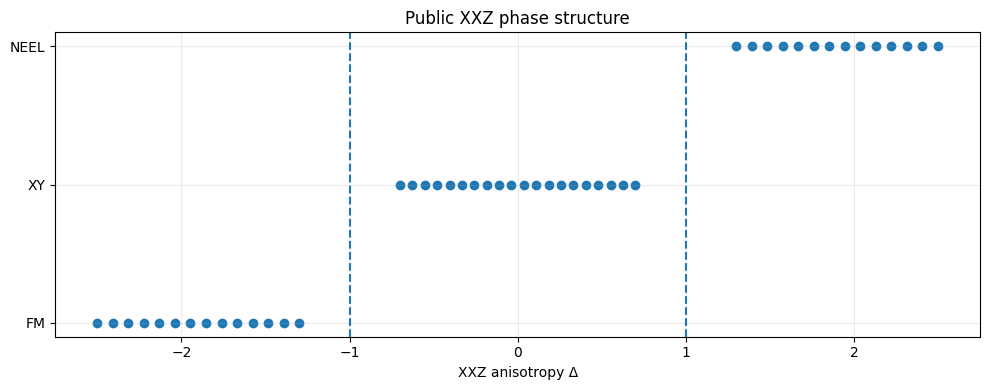

public states within ±0.10 of Δ=±1: 0
public states within ±0.20 of Δ=±1: 0
public states within ±0.30 of Δ=±1: 0
Public near-critical evidence available: False


In [48]:
# ============================================================
# 5. Public critical-region audit
# ============================================================
fig, ax = plt.subplots(figsize=(10, 4))
phase_y = {"FM": 0, "XY": 1, "NEEL": 2}
ax.scatter(meta["delta"], [phase_y[x] for x in meta["label"]])
ax.axvline(-1.0, linestyle="--")
ax.axvline(+1.0, linestyle="--")
ax.set_yticks([0, 1, 2], ["FM", "XY", "NEEL"])
ax.set_xlabel("XXZ anisotropy Δ")
ax.set_title("Public XXZ phase structure")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "public_phase_structure.png", dpi=180)
plt.show()

critical_counts = {}
for width in [0.10, 0.20, 0.30]:
    mask = (np.abs(DELTAS + 1) <= width) | (np.abs(DELTAS - 1) <= width)
    critical_counts[width] = int(mask.sum())
    print(f"public states within ±{width:.2f} of Δ=±1:", int(mask.sum()))

PUBLIC_NEAR_CRITICAL_AVAILABLE = any(v > 0 for v in critical_counts.values())
print("Public near-critical evidence available:", PUBLIC_NEAR_CRITICAL_AVAILABLE)


# 6. Dataset geometry audit — V12's central correction

The rows are not assumed independent. We explicitly measure:

- pure-state fidelity geometry;
- nearest-neighbour fidelity within each phase;
- effective rank of the 48×48 state Gram/fidelity matrices;
- low-dimensional physical-observable geometry;
- how close every validation state is to its nearest training state.

This is a **diagnostic of physical diversity**, not a replacement for the official sample count.


In [49]:
# ============================================================
# 6A. Pairwise fidelity + effective-rank audit
# ============================================================
STATE_GRAM = PUBLIC_STATES @ PUBLIC_STATES.conj().T
FIDELITY_GRAM = np.abs(STATE_GRAM) ** 2

def effective_rank_psd(M, eps=1e-14):
    vals = np.linalg.eigvalsh((M + M.conj().T) / 2)
    vals = np.clip(np.real(vals), 0, None)
    if vals.sum() <= eps:
        return 0.0
    p = vals / vals.sum()
    p = p[p > eps]
    return float(np.exp(-np.sum(p * np.log(p))))

state_gram_erank = effective_rank_psd(STATE_GRAM)
fidelity_gram_erank = effective_rank_psd(FIDELITY_GRAM)

geometry_rows = []
for label in LABEL_ORDER:
    idx = np.where(LABELS == label)[0]
    sub = FIDELITY_GRAM[np.ix_(idx, idx)]
    off = sub[np.triu_indices_from(sub, k=1)]
    sorted_idx = idx[np.argsort(DELTAS[idx])]
    adjacent = [FIDELITY_GRAM[a,b] for a,b in zip(sorted_idx[:-1], sorted_idx[1:])]
    geometry_rows.append({
        "label": label,
        "n": len(idx),
        "pairwise_fidelity_mean": float(np.mean(off)) if len(off) else np.nan,
        "pairwise_fidelity_median": float(np.median(off)) if len(off) else np.nan,
        "adjacent_delta_fidelity_mean": float(np.mean(adjacent)) if adjacent else np.nan,
        "adjacent_delta_fidelity_min": float(np.min(adjacent)) if adjacent else np.nan,
    })

geometry_df = pd.DataFrame(geometry_rows)
display(geometry_df)
print("State Gram effective rank   :", round(state_gram_erank, 6))
print("Fidelity Gram effective rank:", round(fidelity_gram_erank, 6))

nearest_same = []
for i in range(len(meta)):
    cand = np.where((LABELS == LABELS[i]) & (np.arange(len(meta)) != i))[0]
    nearest_same.append(float(np.max(FIDELITY_GRAM[i, cand])) if len(cand) else np.nan)
meta["nearest_same_phase_fidelity"] = nearest_same
print("Median nearest same-phase fidelity:", float(np.nanmedian(nearest_same)))

geometry_df.to_csv(RESULTS_DIR / "dataset_fidelity_geometry.csv", index=False)
meta.to_csv(RESULTS_DIR / "dataset_state_metadata_with_fidelity.csv", index=False)


,label,n,pairwise_fidelity_mean,pairwise_fidelity_median,adjacent_delta_fidelity_mean,adjacent_delta_fidelity_min
0,FM,14,1.000000,1.000000,1.000000,1.000000
1,XY,20,0.901263,0.941240,0.998178,0.995644
2,NEEL,14,0.933113,0.961696,0.998005,0.997527


State Gram effective rank   : 2.701952
Fidelity Gram effective rank: 3.156603
Median nearest same-phase fidelity: 0.9987478127892415


In [50]:
# ============================================================
# 6B. Exact local-observable geometry + PCA intrinsic dimension
# ============================================================
def exact_physics_observables(states):
    states = np.asarray(states, np.complex128)
    n_states, dim = states.shape
    n = int(round(np.log2(dim)))
    basis = np.arange(dim, dtype=np.uint64)
    bit_positions = np.arange(n-1, -1, -1, dtype=np.uint64)
    bits = ((basis[:,None] >> bit_positions[None,:]) & 1).astype(np.int8)
    z = 1.0 - 2.0*bits
    probs = np.abs(states)**2
    out = []
    for sidx, psi in enumerate(states):
        p = probs[sidx]
        mz = float(np.sum(p[:,None] * z) / n)
        mstag = float(np.sum(p[:,None] * (z*((-1.0)**np.arange(n))[None,:])) / n)
        czz = float(np.mean([np.sum(p * z[:,i] * z[:,(i+1)%n]) for i in range(n)]))
        cxx_terms = []
        for i in range(n):
            j = (i+1)%n
            mask = (1 << (n-1-i)) | (1 << (n-1-j))
            flipped = np.bitwise_xor(np.arange(dim, dtype=np.uint64), np.uint64(mask)).astype(np.int64)
            cxx_terms.append(np.real(np.vdot(psi, psi[flipped])))
        cxx = float(np.mean(cxx_terms))
        out.append([mz, mstag, czz, cxx])
    return np.asarray(out, float)

EXACT_PHYS = exact_physics_observables(PUBLIC_STATES)
EXACT_PHYS_NAMES = ["Mz", "Mstag_z", "Czz_nn", "Cxx_nn"]
phys_df = pd.DataFrame(EXACT_PHYS, columns=EXACT_PHYS_NAMES)
phys_df.insert(0, "label", LABELS)
phys_df.insert(0, "delta", DELTAS)
phys_df.insert(0, "id", IDS)
display(phys_df.head())

Xs = StandardScaler().fit_transform(EXACT_PHYS)
pca = PCA().fit(Xs)
pca_df = pd.DataFrame({
    "PC": np.arange(1, len(pca.explained_variance_ratio_)+1),
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative": np.cumsum(pca.explained_variance_ratio_),
})
display(pca_df)
phys_df.to_csv(RESULTS_DIR / "exact_physics_observables.csv", index=False)
pca_df.to_csv(RESULTS_DIR / "physics_intrinsic_dimension_pca.csv", index=False)


,id,delta,label,Mz,Mstag_z,Czz_nn,Cxx_nn
0,T00,-2.500000,FM,1.0,4.563033e-25,1.0,1.072489e-14
1,T01,-2.407692,FM,1.0,-1.233413e-21,1.0,-1.032554e-11
2,T02,-2.315385,FM,1.0,-1.506142e-24,1.0,1.305812e-12
3,T03,-2.223077,FM,1.0,7.100052e-24,1.0,-1.318005e-12
4,T04,-2.130769,FM,1.0,-6.224211e-24,1.0,3.420238e-13


,PC,explained_variance_ratio,cumulative
0,1,0.726927,0.726927
1,2,0.242401,0.969328
2,3,0.030159,0.999487
3,4,0.000513,1.000000


# 7. Validation design

V12 uses one **primary nested split** for model selection and two untouched stress splits:

1. **Primary balanced holdout** — continuity with V11/V9.2.
2. **Boundary-proxy holdout** — reserves the public states closest to `Δ≈±1` that actually exist.
3. **Fidelity-gap holdout** — within each class, greedily/combinatorially chooses a holdout whose nearest remaining train state has the lowest possible fidelity. This directly exposes how little independent state-space coverage the public set offers.

Only the primary inner split is used to tune architectures/hyperparameters. The stress splits are never used for tuning.


In [51]:
# ============================================================
# 7A. Primary nested split
# ============================================================
def balanced_holdout_from_indices(df, indices, frac=0.25):
    indices = np.asarray(indices, int)
    sub = df.loc[indices]
    train, hold = [], []
    for _, g in sub.groupby("label", sort=False):
        g = g.sort_values("delta")
        idx = list(g.index)
        m = max(1, int(round(len(idx) * frac)))
        pos = sorted(set(np.linspace(0, len(idx)-1, m, dtype=int).tolist()))
        h = [idx[p] for p in pos]
        hold.extend(h)
        hset = set(h)
        train.extend([i for i in idx if i not in hset])
    return np.asarray(sorted(train), int), np.asarray(sorted(hold), int)

ALL_IDX = np.arange(len(meta), dtype=int)
FIT_IDX, VAL_IDX = balanced_holdout_from_indices(meta, ALL_IDX, frac=0.25)
SEARCH_TRAIN_IDX, SEARCH_TUNE_IDX = balanced_holdout_from_indices(meta, FIT_IDX, frac=0.28)

assert set(VAL_IDX).isdisjoint(set(FIT_IDX))
assert set(SEARCH_TRAIN_IDX).isdisjoint(set(SEARCH_TUNE_IDX))
assert set(SEARCH_TRAIN_IDX).union(set(SEARCH_TUNE_IDX)).issubset(set(FIT_IDX))

print("Outer FIT:", len(FIT_IDX), dict(Counter(LABELS[FIT_IDX])))
print("Outer VAL:", len(VAL_IDX), dict(Counter(LABELS[VAL_IDX])))
print("Inner SEARCH_TRAIN:", len(SEARCH_TRAIN_IDX), dict(Counter(LABELS[SEARCH_TRAIN_IDX])))
print("Inner SEARCH_TUNE :", len(SEARCH_TUNE_IDX), dict(Counter(LABELS[SEARCH_TUNE_IDX])))
print("Primary nested split: PASS")


Outer FIT: 35 {np.str_('FM'): 10, np.str_('XY'): 15, np.str_('NEEL'): 10}
Outer VAL: 13 {np.str_('FM'): 4, np.str_('XY'): 5, np.str_('NEEL'): 4}
Inner SEARCH_TRAIN: 25 {np.str_('FM'): 7, np.str_('XY'): 11, np.str_('NEEL'): 7}
Inner SEARCH_TUNE : 10 {np.str_('FM'): 3, np.str_('XY'): 4, np.str_('NEEL'): 3}
Primary nested split: PASS


In [52]:
# ============================================================
# 7B. Boundary-proxy and fidelity-gap stress splits
# ============================================================
def boundary_proxy_split(df, frac=0.25):
    hold = []
    for label, g in df.groupby("label", sort=False):
        g = g.sort_values("delta")
        idx = list(g.index)
        m = max(1, int(round(len(idx)*frac)))
        if label == "FM":
            h = idx[-m:]                   # closest available points to Δ=-1
        elif label == "NEEL":
            h = idx[:m]                    # closest available points to Δ=+1
        else:
            lo = (m+1)//2
            hi = m-lo
            h = idx[:lo] + (idx[-hi:] if hi else [])  # both XY boundaries
        hold.extend(h)
    hold = np.asarray(sorted(set(hold)), int)
    train = np.asarray(sorted(set(df.index) - set(hold)), int)
    return train, hold

def best_fidelity_gap_holdout_for_class(class_indices, m):
    idx = np.asarray(sorted(class_indices), int)
    # Brute force is small here: max C(20,5)=15504.
    best = None
    for comb in combinations(idx.tolist(), int(m)):
        hold = np.asarray(comb, int)
        train = np.asarray([i for i in idx if i not in set(comb)], int)
        if len(train) == 0:
            continue
        nearest = [float(np.max(FIDELITY_GRAM[h, train])) for h in hold]
        objective = (float(np.max(nearest)), float(np.mean(nearest)))
        if best is None or objective < best[0]:
            best = (objective, hold)
    return best[1]

def fidelity_gap_split(df, frac=0.25):
    hold = []
    for label, g in df.groupby("label", sort=False):
        idx = np.asarray(g.index, int)
        m = max(1, int(round(len(idx)*frac)))
        hold.extend(best_fidelity_gap_holdout_for_class(idx, m).tolist())
    hold = np.asarray(sorted(set(hold)), int)
    train = np.asarray(sorted(set(df.index) - set(hold)), int)
    return train, hold

BOUNDARY_TRAIN_IDX, BOUNDARY_VAL_IDX = boundary_proxy_split(meta, frac=0.25)
FIDGAP_TRAIN_IDX, FIDGAP_VAL_IDX = fidelity_gap_split(meta, frac=0.25)

STRESS_SPLITS = {
    "PRIMARY_BALANCED": (FIT_IDX, VAL_IDX),
    "BOUNDARY_PROXY": (BOUNDARY_TRAIN_IDX, BOUNDARY_VAL_IDX),
    "FIDELITY_GAP": (FIDGAP_TRAIN_IDX, FIDGAP_VAL_IDX),
}

def split_fidelity_summary(name, train_idx, val_idx):
    rows = []
    for v in val_idx:
        same_train = train_idx[LABELS[train_idx] == LABELS[v]]
        nearest = float(np.max(FIDELITY_GRAM[v, same_train])) if len(same_train) else np.nan
        rows.append({"split":name, "state_index":int(v), "id":IDS[v], "label":LABELS[v], "delta":float(DELTAS[v]), "nearest_same_class_train_fidelity":nearest})
    return pd.DataFrame(rows)

split_fidelity_df = pd.concat([
    split_fidelity_summary(name, tr, va)
    for name,(tr,va) in STRESS_SPLITS.items()
], ignore_index=True)

display(split_fidelity_df.groupby("split")["nearest_same_class_train_fidelity"].agg(["mean","median","min","max"]))
split_fidelity_df.to_csv(RESULTS_DIR / "validation_split_fidelity_gap.csv", index=False)


,mean,median,min,max
split,,,,
BOUNDARY_PROXY,0.990354,0.997089,0.961696,1.0
FIDELITY_GAP,0.982894,0.990664,0.927162,1.0
PRIMARY_BALANCED,0.998615,0.998825,0.995644,1.0


In [53]:
# ============================================================
# 8. Shared helpers + common-random-number sampler
# ============================================================
def pair_starts(n, parity):
    starts = list(range(int(parity), int(n)-1, 2))
    if int(n) % 2 == 0 and int(parity) == 1:
        starts.append(int(n)-1)
    return starts

def index_to_bits(index, n):
    return ((int(index) >> np.arange(n-1, -1, -1)) & 1).astype(np.int8)

def deterministic_uniform(seed, shot_id):
    rng = np.random.default_rng(int(seed) + 104729 * int(shot_id))
    return float(rng.random())

def sample_index_from_uniform(probs, u):
    probs = np.asarray(probs, float)
    cdf = np.cumsum(probs)
    cdf[-1] = 1.0
    return int(np.searchsorted(cdf, float(u), side="right"))

def apply_readout_bitflip(bits, p, seed, shot_id):
    bits = np.asarray(bits, np.int8).copy()
    if p <= 0:
        return bits
    rng = np.random.default_rng(int(seed) + 1000003 + 8191*int(shot_id))
    flips = rng.random(len(bits)) < float(p)
    return np.bitwise_xor(bits, flips.astype(np.int8))


# 9. Direct-state QML architectures

All direct-state candidates act on the unknown quantum copy itself and then use the **same 12D shot estimator + StandardScaler + balanced LogisticRegression head**. This controls the downstream classical processing and isolates the circuit architecture as much as practical.


In [54]:
# ============================================================
# 9A. Exact V9.2 M2 QCNN-inspired local circuit
# ============================================================
def make_m2_ops(params, parity=0):
    p = np.asarray(params, float).reshape(-1)
    assert len(p) == 6
    def ops(wires):
        n = len(wires)
        for a in pair_starts(n, parity):
            b = (a + 1) % n
            qml.RY(float(p[0]), wires=a)
            qml.RY(float(p[1]), wires=b)
            qml.CNOT(wires=[a, b])
            qml.RZ(float(p[2]), wires=b)
        for a in pair_starts(n, 1-int(parity)):
            b = (a + 1) % n
            qml.RY(float(p[3]), wires=a)
            qml.CNOT(wires=[b, a])
            qml.RX(float(p[4]), wires=b)
            qml.RZ(float(p[5]), wires=a)
    return ops


In [55]:
# ============================================================
# 9B. Minimal spatial QRNN — one shared trainable parameter
# ============================================================
def make_qrnn_minimal_ops(params, parity=0):
    p = np.asarray(params, float).reshape(-1)
    assert len(p) == 1
    theta = float(p[0])
    def cell(a, b):
        qml.RY(theta, wires=a)
        qml.CNOT(wires=[a, b])
        qml.CNOT(wires=[b, a])
    def ops(wires):
        n = len(wires)
        if int(parity) == 0:
            for a in range(n-1):
                cell(a, a+1)
        else:
            for a in range(n-1, 0, -1):
                cell(a, a-1)
    return ops


In [56]:
# ============================================================
# 9C. Shared TTN — six parameters reused at every tree node
# ============================================================
def ttn_pair_block(a, b, p):
    qml.RY(float(p[0]), wires=a)
    qml.RY(float(p[1]), wires=b)
    qml.IsingXX(float(p[2]), wires=[a, b])
    qml.IsingZZ(float(p[3]), wires=[a, b])
    qml.CNOT(wires=[a, b])
    qml.RY(float(p[4]), wires=b)
    qml.RZ(float(p[5]), wires=b)

def make_ttn_ops(params, parity=0):
    p = np.asarray(params, float).reshape(-1)
    assert len(p) == 6
    def ops(wires):
        active = list(wires)
        # parity changes which end becomes the first tree leaf without changing parameter count.
        if int(parity) == 1:
            active = active[1:] + active[:1]
        while len(active) > 1:
            nxt = []
            i = 0
            while i + 1 < len(active):
                a, b = active[i], active[i+1]
                ttn_pair_block(a, b, p)
                nxt.append(b)
                i += 2
            if i < len(active):
                nxt.append(active[i])
            active = nxt
    return ops


In [57]:
# ============================================================
# 9D. Shared MERA-inspired circuit — optional 8P challenger
# ============================================================
def mera_disentangler(a, b, p):
    qml.IsingXX(float(p[0]), wires=[a,b])
    qml.IsingYY(float(p[1]), wires=[a,b])
    qml.RZ(float(p[2]), wires=a)
    qml.RZ(float(p[3]), wires=b)

def mera_pool(a, b, p):
    qml.CNOT(wires=[a,b])
    qml.RY(float(p[4]), wires=b)
    qml.IsingZZ(float(p[5]), wires=[a,b])
    qml.RX(float(p[6]), wires=a)
    qml.RZ(float(p[7]), wires=b)

def make_mera_ops(params, parity=0):
    p = np.asarray(params, float).reshape(-1)
    assert len(p) == 8
    def ops(wires):
        active = list(wires)
        if int(parity) == 1:
            active = active[1:] + active[:1]
        while len(active) > 1:
            # Disentangle across neighboring tree blocks first.
            for i in range(1, len(active)-1, 2):
                mera_disentangler(active[i], active[i+1], p)
            nxt = []
            i = 0
            while i + 1 < len(active):
                a, b = active[i], active[i+1]
                mera_pool(a, b, p)
                nxt.append(b)
                i += 2
            if i < len(active):
                nxt.append(active[i])
            active = nxt
    return ops


In [58]:
# ============================================================
# 10. Direct architecture registry + parameter accounting
# ============================================================
DIRECT_ARCHITECTURES = {
    "M2_QCNN_LOCAL_6P": {"n_params":6, "builder":make_m2_ops, "family":"QCNN-inspired local", "official_runtime_candidate":True},
    "QRNN_MINIMAL_1P": {"n_params":1, "builder":make_qrnn_minimal_ops, "family":"minimal spatial recurrent", "official_runtime_candidate":True},
    "SHARED_TTN_6P": {"n_params":6, "builder":make_ttn_ops, "family":"shared TTN-inspired", "official_runtime_candidate":True},
}
if ENABLE_MERA:
    DIRECT_ARCHITECTURES["SHARED_MERA_8P"] = {"n_params":8, "builder":make_mera_ops, "family":"shared MERA-inspired", "official_runtime_candidate":True}

ACTIVE_DIRECT_MODELS = list(DIRECT_ARCHITECTURES)
param_df = pd.DataFrame([
    {"model":name, "family":cfg["family"], "trainable_quantum_parameters":cfg["n_params"], "depends_on_N":False, "official_runtime_candidate":cfg["official_runtime_candidate"]}
    for name,cfg in DIRECT_ARCHITECTURES.items()
])
display(param_df)
assert not param_df["depends_on_N"].any()
print("Direct-model parameter-count independence from N: PASS")


,model,family,trainable_quantum_parameters,depends_on_N,official_runtime_candidate
0,M2_QCNN_LOCAL_6P,QCNN-inspired local,6,False,True
1,QRNN_MINIMAL_1P,minimal spatial recurrent,1,False,True
2,SHARED_TTN_6P,shared TTN-inspired,6,False,True


Direct-model parameter-count independence from N: PASS


In [59]:
# ============================================================
# 11. Shared direct 12D shot feature / aggregation
# ============================================================
DIRECT_FEATURE_NAMES = [
    "pair_control_mean", "pair_target_mean", "pair_product_mean",
    "global_magnetization", "staggered_magnetization", "nn_correlation",
]

def direct_shot_feature(bits, parity):
    bits = np.asarray(bits, int).reshape(-1)
    n = len(bits)
    z = 1.0 - 2.0*bits
    controls, targets, products = [], [], []
    for a in pair_starts(n, parity):
        b = (a+1)%n
        sa, sb = z[a], z[b]
        controls.append(sa); targets.append(sb); products.append(sa*sb)
    return np.asarray([
        np.mean(controls) if controls else 0.0,
        np.mean(targets) if targets else 0.0,
        np.mean(products) if products else 0.0,
        np.mean(z),
        np.mean(((-1.0)**np.arange(n))*z),
        np.mean(z*np.roll(z,-1)),
    ], float)

def aggregate_direct_episode(shots):
    by_parity = {0:[], 1:[]}
    for parity,bits in shots:
        by_parity[int(parity)].append(direct_shot_feature(bits, int(parity)))
    out=[]
    for parity in [0,1]:
        out.append(np.mean(by_parity[parity], axis=0) if by_parity[parity] else np.zeros(6))
    return np.concatenate(out)

DIRECT_FEATURE_DIM = 12
print("Direct feature dimension:", DIRECT_FEATURE_DIM)


Direct feature dimension: 12


In [60]:
# ============================================================
# 12. Memory-safe direct probability simulator
# ============================================================
_DIRECT_QNODES = {}
_DIRECT_PROB_CACHE = {}

def direct_prob_qnode(n, arch, parity):
    key = (int(n), str(arch), int(parity))
    if key in _DIRECT_QNODES:
        return _DIRECT_QNODES[key]
    dev = qml.device("default.qubit", wires=int(n), shots=None)
    builder = DIRECT_ARCHITECTURES[arch]["builder"]
    @qml.qnode(dev)
    def circuit(state, params):
        qml.StatePrep(state, wires=range(int(n)), normalize=True)
        builder(params, parity=int(parity))(range(int(n)))
        return qml.probs(wires=range(int(n)))
    _DIRECT_QNODES[key] = circuit
    return circuit

def param_key(params):
    return tuple(np.round(np.asarray(params, float).reshape(-1), 10))

def get_direct_probs(state_index, arch, params, parity):
    key = (int(state_index), str(arch), param_key(params), int(parity))
    if key not in _DIRECT_PROB_CACHE:
        probs = np.asarray(direct_prob_qnode(N_PUBLIC, arch, parity)(PUBLIC_STATES[int(state_index)], np.asarray(params,float)), float)
        probs = np.maximum(probs, 0.0); probs /= probs.sum()
        _DIRECT_PROB_CACHE[key] = probs
    return _DIRECT_PROB_CACHE[key]

def clear_direct_prob_cache():
    _DIRECT_PROB_CACHE.clear()

def simulate_direct_episode(state_index, arch, params, budget, seed, readout_p=0.0):
    shots=[]
    for shot_id in range(int(budget)):
        parity = shot_id % 2
        probs = get_direct_probs(state_index, arch, params, parity)
        outcome = sample_index_from_uniform(probs, deterministic_uniform(seed, shot_id))
        bits = index_to_bits(outcome, N_PUBLIC)
        bits = apply_readout_bitflip(bits, readout_p, seed, shot_id)
        shots.append((parity,bits))
    return aggregate_direct_episode(shots)

print("Direct-state finite-copy simulator: READY")


Direct-state finite-copy simulator: READY


# 13. Measurement branches for projected-kernel and shadow models

These models do **not** receive the full statevector at inference. Their descriptors are generated from the same copy budget.

- `PROJECTED_QSVM`: half `Z`, half `X` copies → six translation-aggregated observables → auxiliary 4-qubit projected feature map → projected kernel.
- `LOW_COPY_SHADOW_KERNEL_SVM`: each copy uses one of global `X/Y/Z` Pauli bases chosen by a deterministic seed schedule → nine translation-aggregated shadow-style statistics → nonlinear kernel.

The shadow branch is deliberately **low-copy and translation-aggregated**; it is not claimed to reproduce a full local classical-shadow protocol with independently randomized basis on every qubit.


In [61]:
# ============================================================
# 13A. Neutral X/Z finite-copy descriptor
# ============================================================
_NEUTRAL_QNODES = {}
_NEUTRAL_PROB_CACHE = {}
NEUTRAL_FEATURE_NAMES = ["Mz_global","Mz_staggered","Czz_nn","Mx_global","Mx_staggered","Cxx_nn"]

def measurement_prob_qnode(n, basis):
    key = (int(n), str(basis))
    if key in _NEUTRAL_QNODES:
        return _NEUTRAL_QNODES[key]
    dev = qml.device("default.qubit", wires=int(n), shots=None)
    @qml.qnode(dev)
    def circuit(state):
        qml.StatePrep(state, wires=range(int(n)), normalize=True)
        if basis == "X":
            for w in range(int(n)): qml.Hadamard(wires=w)
        elif basis == "Y":
            for w in range(int(n)):
                qml.adjoint(qml.S)(wires=w); qml.Hadamard(wires=w)
        elif basis != "Z":
            raise ValueError(basis)
        return qml.probs(wires=range(int(n)))
    _NEUTRAL_QNODES[key] = circuit
    return circuit

def get_measurement_probs(state_index, basis):
    key=(int(state_index),str(basis))
    if key not in _NEUTRAL_PROB_CACHE:
        p=np.asarray(measurement_prob_qnode(N_PUBLIC,basis)(PUBLIC_STATES[int(state_index)]),float)
        p=np.maximum(p,0.0); p/=p.sum(); _NEUTRAL_PROB_CACHE[key]=p
    return _NEUTRAL_PROB_CACHE[key]

def axis_bit_feature(bits):
    bits=np.asarray(bits,int).reshape(-1)
    z=1.0-2.0*bits; n=len(z)
    return np.asarray([np.mean(z), np.mean(((-1.0)**np.arange(n))*z), np.mean(z*np.roll(z,-1))],float)

def simulate_neutral_episode(state_index,budget,seed,readout_p=0.0):
    budget=int(budget); z_count=budget//2
    zr=[]; xr=[]
    for shot_id in range(budget):
        basis="Z" if shot_id<z_count else "X"
        p=get_measurement_probs(state_index,basis)
        outcome=sample_index_from_uniform(p,deterministic_uniform(seed,shot_id))
        bits=apply_readout_bitflip(index_to_bits(outcome,N_PUBLIC),readout_p,seed,shot_id)
        (zr if basis=="Z" else xr).append(axis_bit_feature(bits))
    return np.concatenate([np.mean(zr,axis=0) if zr else np.zeros(3), np.mean(xr,axis=0) if xr else np.zeros(3)])


In [62]:
# ============================================================
# 13B. Low-copy global-Pauli shadow-style descriptor
# ============================================================
SHADOW_FEATURE_NAMES = [
    "Mx_global","Mx_staggered","Cxx_nn",
    "My_global","My_staggered","Cyy_nn",
    "Mz_global","Mz_staggered","Czz_nn",
]

def shadow_basis_schedule(seed, shot_id):
    # Balanced deterministic schedule with seed-dependent phase offset.
    offset = int(seed) % 3
    return ["X","Y","Z"][(int(shot_id)+offset)%3]

def simulate_shadow_episode(state_index,budget,seed,readout_p=0.0):
    rows={"X":[],"Y":[],"Z":[]}
    for shot_id in range(int(budget)):
        basis=shadow_basis_schedule(seed,shot_id)
        p=get_measurement_probs(state_index,basis)
        outcome=sample_index_from_uniform(p,deterministic_uniform(seed+7919,shot_id))
        bits=apply_readout_bitflip(index_to_bits(outcome,N_PUBLIC),readout_p,seed+17,shot_id)
        rows[basis].append(axis_bit_feature(bits))
    out=[]
    for basis in ["X","Y","Z"]:
        out.append(np.mean(rows[basis],axis=0) if rows[basis] else np.zeros(3))
    return np.concatenate(out)

print("Neutral descriptor dim:", len(NEUTRAL_FEATURE_NAMES))
print("Shadow-style descriptor dim:", len(SHADOW_FEATURE_NAMES))


Neutral descriptor dim: 6
Shadow-style descriptor dim: 9


In [63]:
# ============================================================
# 14. Finite-copy dataset builders with explicit original-state groups
# ============================================================
def fit_linear_phase_head(X,y):
    model=make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000,class_weight="balanced",random_state=GLOBAL_SEED))
    model.fit(X,y); return model

def build_direct_episodes(indices,arch,params,budget,n_episodes,seed_base,readout_p=0.0,return_groups=False):
    X=[]; y=[]; groups=[]
    for idx in np.asarray(indices,int):
        truth=str(meta.loc[int(idx),"label"])
        for ep in range(int(n_episodes)):
            seed=int(seed_base+100000*int(idx)+1000*int(budget)+ep)
            X.append(simulate_direct_episode(idx,arch,params,budget,seed,readout_p)); y.append(truth); groups.append(int(idx))
    data=(np.asarray(X,float),np.asarray(y,str))
    return (*data,np.asarray(groups,int)) if return_groups else data

def build_neutral_episodes(indices,budget,n_episodes,seed_base,readout_p=0.0,return_groups=False):
    X=[]; y=[]; groups=[]
    for idx in np.asarray(indices,int):
        truth=str(meta.loc[int(idx),"label"])
        for ep in range(int(n_episodes)):
            seed=int(seed_base+100000*int(idx)+1000*int(budget)+ep)
            X.append(simulate_neutral_episode(idx,budget,seed,readout_p)); y.append(truth); groups.append(int(idx))
    data=(np.asarray(X,float),np.asarray(y,str))
    return (*data,np.asarray(groups,int)) if return_groups else data

def build_shadow_episodes(indices,budget,n_episodes,seed_base,readout_p=0.0,return_groups=False):
    X=[]; y=[]; groups=[]
    for idx in np.asarray(indices,int):
        truth=str(meta.loc[int(idx),"label"])
        for ep in range(int(n_episodes)):
            seed=int(seed_base+100000*int(idx)+1000*int(budget)+ep)
            X.append(simulate_shadow_episode(idx,budget,seed,readout_p)); y.append(truth); groups.append(int(idx))
    data=(np.asarray(X,float),np.asarray(y,str))
    return (*data,np.asarray(groups,int)) if return_groups else data

def evaluate_predictor_on_states(indices,budget,seeds,predict_feature_fn,predict_from_feature_fn,feature_fn):
    seed_scores=[]; rows=[]
    for seed in seeds:
        yt=[]; yp=[]
        for idx in np.asarray(indices,int):
            feat=feature_fn(int(idx),int(budget),int(seed+100000*int(idx)+17*int(budget)))
            pred=str(predict_from_feature_fn(predict_feature_fn,feat))
            truth=str(meta.loc[int(idx),"label"])
            yt.append(truth); yp.append(pred)
            rows.append({"seed":int(seed),"state_index":int(idx),"id":IDS[int(idx)],"truth":truth,"pred":pred,"budget":int(budget)})
        seed_scores.append(f1_score(yt,yp,labels=LABEL_ORDER,average="macro",zero_division=0))
    return {"mean":float(np.mean(seed_scores)),"std":float(np.std(seed_scores)),"seed_scores":seed_scores,"rows":pd.DataFrame(rows)}


# 15. Projected Quantum Kernel (P-QSVM)

Instead of a global fidelity kernel, V12 maps the six finite-copy physical descriptors into a small 4-qubit feature map and then **projects that quantum state back to local one- and two-body expectation values**. The final kernel is an RBF in that projected representation. This directly implements the projected-kernel principle: low-dimensional physical projections are preferred when the original fidelity geometry is too concentrated or the data manifold is tiny.


In [64]:
# ============================================================
# 15A. Auxiliary projected quantum feature map
# ============================================================
_PROJECTED_QNODES={}

def bound_features(X):
    return np.pi*np.tanh(np.asarray(X,float)/2.0)

def projected_feature_qnode(reps=1):
    reps=int(reps)
    if reps in _PROJECTED_QNODES:
        return _PROJECTED_QNODES[reps]
    dev=qml.device("default.qubit",wires=4,shots=None)
    @qml.qnode(dev)
    def circuit(x,scale):
        x=np.asarray(x,float)
        for _ in range(reps):
            for w in range(4):
                qml.RY(float(scale)*float(x[w%len(x)]),wires=w)
            qml.RZ(float(scale)*float(x[4]),wires=0)
            qml.RZ(float(scale)*float(x[5]),wires=2)
            for w in range(4):
                qml.CNOT(wires=[w,(w+1)%4])
        obs=[qml.expval(qml.PauliX(w)) for w in range(4)]
        obs += [qml.expval(qml.PauliZ(w)) for w in range(4)]
        obs += [qml.expval(qml.PauliZ(w) @ qml.PauliZ((w+1)%4)) for w in range(4)]
        return obs
    _PROJECTED_QNODES[reps]=circuit
    return circuit

def projected_quantum_features(X_scaled,scale=1.0,reps=1):
    Xb=bound_features(X_scaled)
    qnode=projected_feature_qnode(reps)
    return np.asarray([qnode(row,float(scale)) for row in Xb],float)

def projected_rbf_kernel(A,B,gamma):
    A=np.asarray(A,float); B=np.asarray(B,float)
    aa=np.sum(A*A,axis=1)[:,None]; bb=np.sum(B*B,axis=1)[None,:]
    d2=np.maximum(aa+bb-2*A@B.T,0.0)
    return np.exp(-float(gamma)*d2)

def fit_projected_qsvm(X,y,cfg):
    scaler=StandardScaler().fit(X)
    A=projected_quantum_features(scaler.transform(X),cfg["scale"],cfg["reps"])
    K=projected_rbf_kernel(A,A,cfg["gamma"])
    svc=SVC(C=float(cfg["C"]),kernel="precomputed",class_weight="balanced",decision_function_shape="ovr")
    svc.fit(K,y)
    return {"scaler":scaler,"proj_train":A,"svc":svc,"cfg":dict(cfg)}

def predict_projected_qsvm(model,X):
    X=np.atleast_2d(np.asarray(X,float))
    A=projected_quantum_features(model["scaler"].transform(X),model["cfg"]["scale"],model["cfg"]["reps"])
    K=projected_rbf_kernel(A,model["proj_train"],model["cfg"]["gamma"])
    return model["svc"].predict(K)


# 16. Low-copy shadow kernel

The shadow branch uses a deliberately stable positive-semidefinite nonlinear kernel on the nine shadow-style observables. It is a **measurement/kernel research model**, not the primary QML submission candidate.


In [65]:
# ============================================================
# 16A. Nonlinear shadow kernel + SVM
# ============================================================
def normalized_dot_kernel(A,B,gamma=1.0,tau=1.0):
    A=np.asarray(A,float); B=np.asarray(B,float)
    an=np.linalg.norm(A,axis=1,keepdims=True); bn=np.linalg.norm(B,axis=1,keepdims=True)
    A=A/np.maximum(an,1e-12); B=B/np.maximum(bn,1e-12)
    base=A@B.T
    # exp(tau * (exp(gamma*dot)-1)) has a non-negative power-series expansion in a PSD dot kernel.
    K=np.exp(float(tau)*(np.exp(float(gamma)*base)-1.0))
    return K

def fit_shadow_svm(X,y,cfg):
    scaler=StandardScaler().fit(X)
    A=scaler.transform(X)
    K=normalized_dot_kernel(A,A,cfg["gamma"],cfg["tau"])
    svc=SVC(C=float(cfg["C"]),kernel="precomputed",class_weight="balanced",decision_function_shape="ovr")
    svc.fit(K,y)
    return {"scaler":scaler,"train":A,"svc":svc,"cfg":dict(cfg)}

def predict_shadow_svm(model,X):
    X=np.atleast_2d(np.asarray(X,float))
    A=model["scaler"].transform(X)
    K=normalized_dot_kernel(A,model["train"],model["cfg"]["gamma"],model["cfg"]["tau"])
    return model["svc"].predict(K)


In [66]:
# ============================================================
# 17. Candidate banks
# ============================================================
def direct_candidate_bank(arch,seed=GLOBAL_SEED):
    rng=np.random.default_rng(seed)
    d=DIRECT_ARCHITECTURES[arch]["n_params"]
    if arch=="QRNN_MINIMAL_1P":
        vals=[0.0,-np.pi/2,np.pi/2,-np.pi/4,np.pi/4]
        return [np.asarray([v],float) for v in vals]
    bank=[np.zeros(d), np.r_[[-np.pi/2],np.zeros(d-1)], np.r_[[np.pi/2],np.zeros(d-1)]]
    if d>=4:
        s=np.zeros(d); s[:min(d,4)]=[-np.pi/4,np.pi/4,np.pi/8,-np.pi/8][:min(d,4)]; bank.append(s)
    for _ in range(DIRECT_RANDOM_CANDIDATES):
        bank.append(rng.uniform(-np.pi/2,np.pi/2,size=d))
    unique=[]; seen=set()
    for p in bank:
        k=tuple(np.round(p,8))
        if k not in seen:
            seen.add(k); unique.append(np.asarray(p,float))
    return unique

PROJECTED_KERNEL_MASTER = [
    {"scale":1.0,"reps":1,"gamma":0.5,"C":1.0},
    {"scale":0.5,"reps":1,"gamma":0.5,"C":1.0},
    {"scale":1.5,"reps":1,"gamma":0.5,"C":1.0},
    {"scale":1.0,"reps":2,"gamma":0.5,"C":1.0},
    {"scale":1.0,"reps":1,"gamma":0.25,"C":1.0},
    {"scale":1.0,"reps":1,"gamma":1.0,"C":1.0},
    {"scale":1.0,"reps":1,"gamma":2.0,"C":1.0},
    {"scale":1.0,"reps":1,"gamma":0.5,"C":0.5},
    {"scale":1.0,"reps":1,"gamma":0.5,"C":2.0},
    {"scale":0.5,"reps":2,"gamma":1.0,"C":1.0},
    {"scale":1.5,"reps":2,"gamma":0.25,"C":1.0},
    {"scale":0.5,"reps":1,"gamma":2.0,"C":2.0},
    {"scale":1.5,"reps":1,"gamma":0.25,"C":0.5},
    {"scale":1.0,"reps":2,"gamma":1.0,"C":2.0},
    {"scale":1.0,"reps":2,"gamma":0.25,"C":0.5},
    {"scale":0.5,"reps":2,"gamma":0.5,"C":2.0},
    {"scale":1.5,"reps":2,"gamma":0.5,"C":0.5},
    {"scale":1.5,"reps":2,"gamma":2.0,"C":2.0},
]
PROJECTED_KERNEL_CANDIDATES = PROJECTED_KERNEL_MASTER[:PROJECTED_KERNEL_MAX_CANDIDATES]

SHADOW_KERNEL_MASTER = [
    {"gamma":0.5,"tau":0.5,"C":1.0},
    {"gamma":0.25,"tau":0.5,"C":1.0},
    {"gamma":1.0,"tau":0.5,"C":1.0},
    {"gamma":0.5,"tau":0.25,"C":1.0},
    {"gamma":0.5,"tau":1.0,"C":1.0},
    {"gamma":0.5,"tau":0.5,"C":2.0},
    {"gamma":0.5,"tau":0.5,"C":0.5},
    {"gamma":1.0,"tau":1.0,"C":1.0},
    {"gamma":0.25,"tau":1.0,"C":2.0},
    {"gamma":1.0,"tau":0.25,"C":0.5},
    {"gamma":0.25,"tau":0.25,"C":1.0},
    {"gamma":1.0,"tau":0.5,"C":2.0},
    {"gamma":0.5,"tau":1.0,"C":0.5},
    {"gamma":0.25,"tau":0.5,"C":2.0},
    {"gamma":1.0,"tau":1.0,"C":2.0},
    {"gamma":0.25,"tau":1.0,"C":0.5},
]
SHADOW_KERNEL_CANDIDATES = SHADOW_KERNEL_MASTER[:SHADOW_KERNEL_MAX_CANDIDATES]

print("Direct candidates:",{a:len(direct_candidate_bank(a)) for a in ACTIVE_DIRECT_MODELS})
print("Projected kernel candidates:",len(PROJECTED_KERNEL_CANDIDATES))
print("Shadow kernel candidates:",len(SHADOW_KERNEL_CANDIDATES))


Direct candidates: {'M2_QCNN_LOCAL_6P': 8, 'QRNN_MINIMAL_1P': 5, 'SHARED_TTN_6P': 8}
Projected kernel candidates: 6
Shadow kernel candidates: 6


In [67]:
# ============================================================
# 18. Inner-search utility
# ============================================================
SEARCH_SEEDS=[101,211,307,401][:SEARCH_REPEATS]

def weighted_from_budget_scores(scores):
    return float(sum(BUDGET_WEIGHTS[b]*float(scores[b]) for b in SCORED_BUDGETS))

def evaluate_direct_candidate(arch,params):
    budget_scores={}
    for b in SCORED_BUDGETS:
        Xtr,ytr=build_direct_episodes(SEARCH_TRAIN_IDX,arch,params,b,TRAIN_EPISODES_PER_STATE,110000+b)
        head=fit_linear_phase_head(Xtr,ytr)
        seed_scores=[]
        for seed in SEARCH_SEEDS:
            yt=[]; yp=[]
            for idx in SEARCH_TUNE_IDX:
                feat=simulate_direct_episode(idx,arch,params,b,int(seed+100000*idx+17*b))
                yt.append(str(LABELS[idx])); yp.append(str(head.predict([feat])[0]))
            seed_scores.append(f1_score(yt,yp,labels=LABEL_ORDER,average="macro",zero_division=0))
        budget_scores[b]=float(np.mean(seed_scores))
    return budget_scores


In [68]:
# ============================================================
# 19. Search direct-state architectures on inner split only
# ============================================================
DIRECT_SEARCH_ROWS=[]; DIRECT_BEST={}
for arch in ACTIVE_DIRECT_MODELS:
    best=None
    print("\nSearching",arch)
    for cid,params in enumerate(direct_candidate_bank(arch,seed=GLOBAL_SEED+len(arch))):
        scores=evaluate_direct_candidate(arch,params)
        weighted=weighted_from_budget_scores(scores)
        row={"model":arch,"candidate":cid,"weighted":weighted,**{f"f1_{b}":scores[b] for b in SCORED_BUDGETS},"params":params.tolist()}
        DIRECT_SEARCH_ROWS.append(row)
        print(cid,"weighted=",round(weighted,6),"params=",np.round(params,4).tolist())
        key=(weighted,-DIRECT_ARCHITECTURES[arch]["n_params"])
        if best is None or key>best[0]:
            best=(key,params.copy(),scores)
        clear_direct_prob_cache()   # never retain every candidate's 16-qubit probability arrays
    DIRECT_BEST[arch]={"params":best[1],"scores":best[2],"weighted":best[0][0]}
    print("BEST",arch,"=",np.round(best[1],6).tolist(),"weighted",best[0][0])

direct_search_df=pd.DataFrame(DIRECT_SEARCH_ROWS)
direct_search_df.to_csv(RESULTS_DIR/"direct_inner_search.csv",index=False)
display(pd.DataFrame([{"model":a,"weighted":v["weighted"],"params":v["params"].tolist()} for a,v in DIRECT_BEST.items()]))



Searching M2_QCNN_LOCAL_6P
0 weighted= 0.944444 params= [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
1 weighted= 0.328194 params= [-1.5708, 0.0, 0.0, 0.0, 0.0, 0.0]
2 weighted= 0.328194 params= [1.5708, 0.0, 0.0, 0.0, 0.0, 0.0]
3 weighted= 0.931481 params= [-0.7854, 0.7854, 0.3927, -0.3927, 0.0, 0.0]
4 weighted= 0.679008 params= [-0.2615, 0.2453, -1.1252, -1.338, 1.413, -1.2967]
5 weighted= 0.778313 params= [0.849, -0.8481, 1.1626, 0.8132, -1.3197, -1.1769]
6 weighted= 0.71127 params= [-1.1502, 1.5378, -1.0324, -0.6981, 0.4848, 1.512]
7 weighted= 0.71744 params= [-1.2733, -0.0768, -1.4851, 0.8895, -0.6723, 1.4583]
BEST M2_QCNN_LOCAL_6P = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0] weighted 0.9444444444444444

Searching QRNN_MINIMAL_1P
0 weighted= 0.930159 params= [0.0]
1 weighted= 0.87629 params= [-1.5708]
2 weighted= 0.87629 params= [1.5708]
3 weighted= 0.964286 params= [-0.7854]
4 weighted= 0.964286 params= [0.7854]
BEST QRNN_MINIMAL_1P = [-0.785398] weighted 0.9642857142857142

Searching SHARED_TTN_6P
0 weig

,model,weighted,params
0,M2_QCNN_LOCAL_6P,0.944444,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
1,QRNN_MINIMAL_1P,0.964286,[-0.7853981633974483]
2,SHARED_TTN_6P,0.830159,"[-1.5707963267948966, 0.0, 0.0, 0.0, 0.0, 0.0]"


In [69]:
# ============================================================
# 20. Search PROJECTED_QSVM on the same inner split
# ============================================================
PROJECTED_SEARCH_ROWS=[]; PROJECTED_BEST=None
for cid,cfg in enumerate(PROJECTED_KERNEL_CANDIDATES):
    scores={}
    for b in SCORED_BUDGETS:
        Xtr,ytr=build_neutral_episodes(SEARCH_TRAIN_IDX,b,TRAIN_EPISODES_PER_STATE,220000+b)
        model=fit_projected_qsvm(Xtr,ytr,cfg)
        ss=[]
        for seed in SEARCH_SEEDS:
            yt=[]; yp=[]
            for idx in SEARCH_TUNE_IDX:
                x=simulate_neutral_episode(idx,b,int(seed+100000*idx+17*b))
                yt.append(str(LABELS[idx])); yp.append(str(predict_projected_qsvm(model,[x])[0]))
            ss.append(f1_score(yt,yp,labels=LABEL_ORDER,average="macro",zero_division=0))
        scores[b]=float(np.mean(ss))
    weighted=weighted_from_budget_scores(scores)
    PROJECTED_SEARCH_ROWS.append({"candidate":cid,"weighted":weighted,**cfg,**{f"f1_{b}":scores[b] for b in SCORED_BUDGETS}})
    if PROJECTED_BEST is None or weighted>PROJECTED_BEST[0]:
        PROJECTED_BEST=(weighted,dict(cfg),scores)
    print("Projected",cid,"weighted=",round(weighted,6),cfg)

projected_search_df=pd.DataFrame(PROJECTED_SEARCH_ROWS)
projected_search_df.to_csv(RESULTS_DIR/"projected_qsvm_inner_search.csv",index=False)
PROJECTED_BEST_CFG=PROJECTED_BEST[1]
print("BEST PROJECTED_QSVM:",PROJECTED_BEST_CFG,"weighted",PROJECTED_BEST[0])


Projected 0 weighted= 0.936806 {'scale': 1.0, 'reps': 1, 'gamma': 0.5, 'C': 1.0}
Projected 1 weighted= 0.879854 {'scale': 0.5, 'reps': 1, 'gamma': 0.5, 'C': 1.0}
Projected 2 weighted= 0.951786 {'scale': 1.5, 'reps': 1, 'gamma': 0.5, 'C': 1.0}
Projected 3 weighted= 0.663446 {'scale': 1.0, 'reps': 2, 'gamma': 0.5, 'C': 1.0}
Projected 4 weighted= 0.936806 {'scale': 1.0, 'reps': 1, 'gamma': 0.25, 'C': 1.0}
Projected 5 weighted= 0.924901 {'scale': 1.0, 'reps': 1, 'gamma': 1.0, 'C': 1.0}
BEST PROJECTED_QSVM: {'scale': 1.5, 'reps': 1, 'gamma': 0.5, 'C': 1.0} weighted 0.9517857142857142


In [70]:
# ============================================================
# 21. Search LOW_COPY_SHADOW_KERNEL_SVM on inner split
# ============================================================
SHADOW_SEARCH_ROWS=[]; SHADOW_BEST=None
for cid,cfg in enumerate(SHADOW_KERNEL_CANDIDATES):
    scores={}
    for b in SCORED_BUDGETS:
        Xtr,ytr=build_shadow_episodes(SEARCH_TRAIN_IDX,b,TRAIN_EPISODES_PER_STATE,330000+b)
        model=fit_shadow_svm(Xtr,ytr,cfg)
        ss=[]
        for seed in SEARCH_SEEDS:
            yt=[]; yp=[]
            for idx in SEARCH_TUNE_IDX:
                x=simulate_shadow_episode(idx,b,int(seed+100000*idx+17*b))
                yt.append(str(LABELS[idx])); yp.append(str(predict_shadow_svm(model,[x])[0]))
            ss.append(f1_score(yt,yp,labels=LABEL_ORDER,average="macro",zero_division=0))
        scores[b]=float(np.mean(ss))
    weighted=weighted_from_budget_scores(scores)
    SHADOW_SEARCH_ROWS.append({"candidate":cid,"weighted":weighted,**cfg,**{f"f1_{b}":scores[b] for b in SCORED_BUDGETS}})
    if SHADOW_BEST is None or weighted>SHADOW_BEST[0]:
        SHADOW_BEST=(weighted,dict(cfg),scores)
    print("Shadow",cid,"weighted=",round(weighted,6),cfg)

shadow_search_df=pd.DataFrame(SHADOW_SEARCH_ROWS)
shadow_search_df.to_csv(RESULTS_DIR/"shadow_kernel_inner_search.csv",index=False)
SHADOW_BEST_CFG=SHADOW_BEST[1]
print("BEST SHADOW KERNEL:",SHADOW_BEST_CFG,"weighted",SHADOW_BEST[0])


Shadow 0 weighted= 0.841005 {'gamma': 0.5, 'tau': 0.5, 'C': 1.0}
Shadow 1 weighted= 0.825 {'gamma': 0.25, 'tau': 0.5, 'C': 1.0}
Shadow 2 weighted= 0.851865 {'gamma': 1.0, 'tau': 0.5, 'C': 1.0}
Shadow 3 weighted= 0.782882 {'gamma': 0.5, 'tau': 0.25, 'C': 1.0}
Shadow 4 weighted= 0.90123 {'gamma': 0.5, 'tau': 1.0, 'C': 1.0}
Shadow 5 weighted= 0.921971 {'gamma': 0.5, 'tau': 0.5, 'C': 2.0}
BEST SHADOW KERNEL: {'gamma': 0.5, 'tau': 0.5, 'C': 2.0} weighted 0.9219708994708995


In [71]:
# ============================================================
# 22. Freeze all primary models on full outer FIT
# ============================================================
FROZEN_MODELS={}
for arch,best in DIRECT_BEST.items():
    params=np.asarray(best["params"],float)
    heads={}
    for b in BUDGETS:
        Xtr,ytr=build_direct_episodes(FIT_IDX,arch,params,b,TRAIN_EPISODES_PER_STATE,440000+b)
        heads[b]=fit_linear_phase_head(Xtr,ytr)
    FROZEN_MODELS[arch]={"kind":"direct","params":params,"heads":heads}

projected_budget_models={}
shadow_budget_models={}
for b in BUDGETS:
    Xn,yn=build_neutral_episodes(FIT_IDX,b,TRAIN_EPISODES_PER_STATE,450000+b)
    projected_budget_models[b]=fit_projected_qsvm(Xn,yn,PROJECTED_BEST_CFG)
    Xs,ys=build_shadow_episodes(FIT_IDX,b,TRAIN_EPISODES_PER_STATE,460000+b)
    shadow_budget_models[b]=fit_shadow_svm(Xs,ys,SHADOW_BEST_CFG)

FROZEN_MODELS["PROJECTED_QSVM"]={"kind":"projected","budget_models":projected_budget_models}
FROZEN_MODELS["LOW_COPY_SHADOW_KERNEL_SVM"]={"kind":"shadow","budget_models":shadow_budget_models}

PRIMARY_MODELS=list(ACTIVE_DIRECT_MODELS)+["PROJECTED_QSVM","LOW_COPY_SHADOW_KERNEL_SVM"]
print("Frozen models:",PRIMARY_MODELS)


Frozen models: ['M2_QCNN_LOCAL_6P', 'QRNN_MINIMAL_1P', 'SHARED_TTN_6P', 'PROJECTED_QSVM', 'LOW_COPY_SHADOW_KERNEL_SVM']


In [72]:
# ============================================================
# 23. Unified public-state prediction / evaluation
# ============================================================
def model_feature(model,idx,budget,seed,readout_p=0.0):
    if model in DIRECT_ARCHITECTURES:
        f=FROZEN_MODELS[model]
        return simulate_direct_episode(idx,model,f["params"],budget,seed,readout_p)
    if model=="PROJECTED_QSVM":
        return simulate_neutral_episode(idx,budget,seed,readout_p)
    if model=="LOW_COPY_SHADOW_KERNEL_SVM":
        return simulate_shadow_episode(idx,budget,seed,readout_p)
    raise ValueError(model)

def predict_from_model_feature(model,budget,feat):
    if model in DIRECT_ARCHITECTURES:
        return str(FROZEN_MODELS[model]["heads"][budget].predict([feat])[0])
    if model=="PROJECTED_QSVM":
        return str(predict_projected_qsvm(FROZEN_MODELS[model]["budget_models"][budget],[feat])[0])
    if model=="LOW_COPY_SHADOW_KERNEL_SVM":
        return str(predict_shadow_svm(FROZEN_MODELS[model]["budget_models"][budget],[feat])[0])
    raise ValueError(model)

def evaluate_model_public(model,indices,budget,seeds,readout_p=0.0):
    scores=[]; rows=[]
    for seed in seeds:
        yt=[]; yp=[]
        for idx in np.asarray(indices,int):
            feat=model_feature(model,int(idx),int(budget),int(seed+100000*idx+17*budget),readout_p)
            pred=predict_from_model_feature(model,budget,feat)
            truth=str(LABELS[idx])
            yt.append(truth); yp.append(pred)
            rows.append({"model":model,"seed":int(seed),"state_index":int(idx),"id":IDS[idx],"delta":float(DELTAS[idx]),"truth":truth,"pred":pred,"budget":int(budget)})
        scores.append(f1_score(yt,yp,labels=LABEL_ORDER,average="macro",zero_division=0))
    return {"mean":float(np.mean(scores)),"std":float(np.std(scores)),"seed_scores":scores,"rows":pd.DataFrame(rows)}


In [73]:
# ============================================================
# 24. Untouched PRIMARY outer-validation evaluation
# ============================================================
FINAL_DETAIL={}; FINAL_ROWS=[]
for model in PRIMARY_MODELS:
    print("\nPRIMARY OUTER VAL:",model)
    for b in BUDGETS:
        ev=evaluate_model_public(model,VAL_IDX,b,REPORT_SEEDS)
        FINAL_DETAIL[(model,b)]=ev
        FINAL_ROWS.append({"model":model,"budget":b,"macro_f1_mean":ev["mean"],"macro_f1_std":ev["std"]})
        print(f"  k={b:2d}: {ev['mean']:.6f} ± {ev['std']:.6f}")

final_df=pd.DataFrame(FINAL_ROWS)
final_df.to_csv(RESULTS_DIR/"primary_outer_validation.csv",index=False)
display(final_df)



PRIMARY OUTER VAL: M2_QCNN_LOCAL_6P
  k= 4: 0.899335 ± 0.034920
  k= 8: 0.925309 ± 0.061239
  k=16: 1.000000 ± 0.000000
  k=32: 1.000000 ± 0.000000
  k=64: 1.000000 ± 0.000000

PRIMARY OUTER VAL: QRNN_MINIMAL_1P
  k= 4: 0.918470 ± 0.068089
  k= 8: 0.975309 ± 0.034919
  k=16: 0.925926 ± 0.000000
  k=32: 0.975309 ± 0.034919
  k=64: 1.000000 ± 0.000000

PRIMARY OUTER VAL: SHARED_TTN_6P
  k= 4: 0.646585 ± 0.102437
  k= 8: 0.779770 ± 0.052693
  k=16: 0.900000 ± 0.070711
  k=32: 0.925309 ± 0.061239
  k=64: 1.000000 ± 0.000000

PRIMARY OUTER VAL: PROJECTED_QSVM
  k= 4: 0.875926 ± 0.092556
  k= 8: 0.975309 ± 0.034919
  k=16: 0.923361 ± 0.001814
  k=32: 0.950617 ± 0.034919
  k=64: 1.000000 ± 0.000000

PRIMARY OUTER VAL: LOW_COPY_SHADOW_KERNEL_SVM
  k= 4: 0.899335 ± 0.034920
  k= 8: 0.874026 ± 0.127100
  k=16: 0.944444 ± 0.078567
  k=32: 0.923361 ± 0.001814
  k=64: 0.975309 ± 0.034919


,model,budget,macro_f1_mean,macro_f1_std
0,M2_QCNN_LOCAL_6P,4,0.899335,0.034920
1,M2_QCNN_LOCAL_6P,8,0.925309,0.061239
2,M2_QCNN_LOCAL_6P,16,1.000000,0.000000
3,M2_QCNN_LOCAL_6P,32,1.000000,0.000000
4,M2_QCNN_LOCAL_6P,64,1.000000,0.000000
5,QRNN_MINIMAL_1P,4,0.918470,0.068089
6,QRNN_MINIMAL_1P,8,0.975309,0.034919
7,QRNN_MINIMAL_1P,16,0.925926,0.000000
8,QRNN_MINIMAL_1P,32,0.975309,0.034919
9,QRNN_MINIMAL_1P,64,1.000000,0.000000


In [74]:
# ============================================================
# 25. Primary low-copy ranking — raw score is primary; stability is secondary
# ============================================================
def weighted_model_summary(df,model):
    g=df[df["model"]==model].set_index("budget")
    weighted=sum(BUDGET_WEIGHTS[b]*float(g.loc[b,"macro_f1_mean"]) for b in SCORED_BUDGETS)
    mean_std=float(np.mean([float(g.loc[b,"macro_f1_std"]) for b in SCORED_BUDGETS]))
    return float(weighted),mean_std,float(weighted-0.10*mean_std)

ranking=[]
for model in PRIMARY_MODELS:
    weighted,mean_std,stability=weighted_model_summary(final_df,model)
    ranking.append({"model":model,"weighted_low_copy_f1":weighted,"mean_low_copy_std":mean_std,"stability_diagnostic":stability,"official_direct_runtime_candidate":model in DIRECT_ARCHITECTURES})
ranking_df=pd.DataFrame(ranking).sort_values(["weighted_low_copy_f1","mean_low_copy_std"],ascending=[False,True]).reset_index(drop=True)
display(ranking_df)
ranking_df.to_csv(RESULTS_DIR/"primary_ranking.csv",index=False)

PUBLIC_RESEARCH_WINNER=str(ranking_df.iloc[0]["model"])
DIRECT_RANKING=ranking_df[ranking_df["official_direct_runtime_candidate"]].reset_index(drop=True)
DIRECT_PUBLIC_WINNER=str(DIRECT_RANKING.iloc[0]["model"])
print("Research winner:",PUBLIC_RESEARCH_WINNER)
print("Best direct-state candidate:",DIRECT_PUBLIC_WINNER)


,model,weighted_low_copy_f1,mean_low_copy_std,stability_diagnostic,official_direct_runtime_candidate
0,QRNN_MINIMAL_1P,0.940228,0.034336,0.936794,True
1,M2_QCNN_LOCAL_6P,0.933592,0.032053,0.930387,True
2,PROJECTED_QSVM,0.922569,0.043096,0.918259,False
3,LOW_COPY_SHADOW_KERNEL_SVM,0.901754,0.080196,0.893734,False
4,SHARED_TTN_6P,0.756554,0.075280,0.749026,True


Research winner: QRNN_MINIMAL_1P
Best direct-state candidate: QRNN_MINIMAL_1P


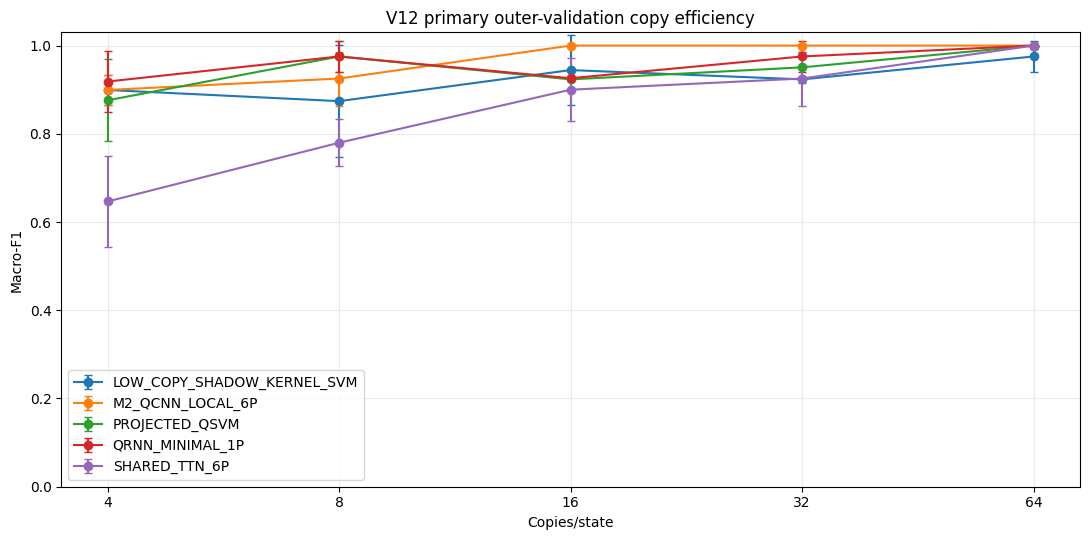

In [75]:
# ============================================================
# 26. Copy-efficiency plot
# ============================================================
fig,ax=plt.subplots(figsize=(11,5.5))
for model,g in final_df.groupby("model"):
    g=g.sort_values("budget")
    ax.errorbar(g["budget"],g["macro_f1_mean"],yerr=g["macro_f1_std"],marker="o",capsize=3,label=model)
ax.set_xscale("log",base=2); ax.set_xticks(BUDGETS,[str(x) for x in BUDGETS]); ax.set_ylim(0,1.03)
ax.set_xlabel("Copies/state"); ax.set_ylabel("Macro-F1"); ax.set_title("V12 primary outer-validation copy efficiency")
ax.grid(alpha=.25); ax.legend(); plt.tight_layout(); plt.savefig(RESULTS_DIR/"primary_copy_efficiency.png",dpi=190); plt.show()


# 27. State-level hierarchical bootstrap

The V11 significance analysis paired seeds, but V12 additionally resamples **original state IDs** rather than shot episodes. Each bootstrap replicate:

1. resamples report seeds with replacement;
2. resamples validation state IDs **within class** with replacement;
3. uses the same sampled seeds/states for both compared models and all scored budgets;
4. recomputes the weighted `4/8/16` Macro-F1 difference.

This is the primary uncertainty analysis for the tiny, correlated dataset.


In [76]:
# ============================================================
# 27A. Prediction lookup + hierarchical paired bootstrap
# ============================================================
PRED_LOOKUP={}
for model in PRIMARY_MODELS:
    for b in SCORED_BUDGETS:
        rows=FINAL_DETAIL[(model,b)]["rows"]
        PRED_LOOKUP[(model,b)]={(int(r.seed),int(r.state_index)):str(r.pred) for r in rows.itertuples()}

def weighted_score_for_sample(model,sampled_seeds,sampled_states_by_class):
    budget_scores={}
    for b in SCORED_BUDGETS:
        yt=[]; yp=[]
        for seed in sampled_seeds:
            for label,states in sampled_states_by_class.items():
                for idx in states:
                    yt.append(str(label)); yp.append(PRED_LOOKUP[(model,b)][(int(seed),int(idx))])
        budget_scores[b]=f1_score(yt,yp,labels=LABEL_ORDER,average="macro",zero_division=0)
    return weighted_from_budget_scores(budget_scores)

def hierarchical_bootstrap_margin(model_a,model_b,n_boot=BOOTSTRAP_REPS,seed=2026):
    rng=np.random.default_rng(seed)
    vals=np.empty(int(n_boot),float)
    class_states={lab:VAL_IDX[LABELS[VAL_IDX]==lab] for lab in LABEL_ORDER}
    for i in range(int(n_boot)):
        sampled_seeds=rng.choice(REPORT_SEEDS,size=len(REPORT_SEEDS),replace=True)
        sampled_states={lab:rng.choice(v,size=len(v),replace=True) for lab,v in class_states.items()}
        vals[i]=weighted_score_for_sample(model_a,sampled_seeds,sampled_states)-weighted_score_for_sample(model_b,sampled_seeds,sampled_states)
    return {
        "mean_margin":float(np.mean(vals)),
        "ci_low":float(np.quantile(vals,.025)),
        "ci_high":float(np.quantile(vals,.975)),
        "p_margin_gt_0":float(np.mean(vals>0)),
    }

bootstrap_rows=[]
for challenger in ranking_df["model"].iloc[1:]:
    res=hierarchical_bootstrap_margin(PUBLIC_RESEARCH_WINNER,str(challenger))
    bootstrap_rows.append({"winner":PUBLIC_RESEARCH_WINNER,"challenger":str(challenger),**res})
bootstrap_df=pd.DataFrame(bootstrap_rows)
display(bootstrap_df)
bootstrap_df.to_csv(RESULTS_DIR/"hierarchical_state_seed_bootstrap.csv",index=False)


,winner,challenger,mean_margin,ci_low,ci_high,p_margin_gt_0
0,QRNN_MINIMAL_1P,M2_QCNN_LOCAL_6P,0.007414,-0.052278,0.071104,0.59000
1,QRNN_MINIMAL_1P,PROJECTED_QSVM,0.017605,-0.037037,0.062832,0.80150
2,QRNN_MINIMAL_1P,LOW_COPY_SHADOW_KERNEL_SVM,0.037988,-0.069895,0.159440,0.78225
3,QRNN_MINIMAL_1P,SHARED_TTN_6P,0.183559,0.064214,0.335090,0.99975


In [77]:
# ============================================================
# 28. Per-class metrics + confusion matrices + error-vs-Δ
# ============================================================
per_class_rows=[]; error_rows=[]
for model in PRIMARY_MODELS:
    for b in SCORED_BUDGETS:
        rows=FINAL_DETAIL[(model,b)]["rows"]
        rep=classification_report(rows["truth"],rows["pred"],labels=LABEL_ORDER,output_dict=True,zero_division=0)
        for lab in LABEL_ORDER:
            per_class_rows.append({"model":model,"budget":b,"class":lab,"precision":rep[lab]["precision"],"recall":rep[lab]["recall"],"f1":rep[lab]["f1-score"]})
        tmp=rows.copy(); tmp["error"]=(tmp["truth"]!=tmp["pred"]).astype(float)
        err=tmp.groupby(["state_index","id","delta","truth"],as_index=False)["error"].mean(); err["model"]=model; err["budget"]=b
        error_rows.append(err)
        cm=confusion_matrix(rows["truth"],rows["pred"],labels=LABEL_ORDER)
        fig,ax=plt.subplots(figsize=(4.8,4.2)); ax.imshow(cm)
        ax.set_xticks(range(3),LABEL_ORDER); ax.set_yticks(range(3),LABEL_ORDER)
        for i in range(3):
            for j in range(3): ax.text(j,i,str(cm[i,j]),ha="center",va="center")
        ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(f"{model} — k={b}")
        plt.tight_layout(); plt.savefig(RESULTS_DIR/f"cm_{model}_k{b}.png",dpi=160); plt.close(fig)

per_class_df=pd.DataFrame(per_class_rows); error_df=pd.concat(error_rows,ignore_index=True)
per_class_df.to_csv(RESULTS_DIR/"per_class_metrics.csv",index=False); error_df.to_csv(RESULTS_DIR/"per_state_error_vs_delta.csv",index=False)
display(per_class_df)


,model,budget,class,precision,recall,f1
0,M2_QCNN_LOCAL_6P,4,FM,1.000000,1.000000,1.000000
1,M2_QCNN_LOCAL_6P,4,XY,0.866667,0.866667,0.866667
2,M2_QCNN_LOCAL_6P,4,NEEL,0.833333,0.833333,0.833333
3,M2_QCNN_LOCAL_6P,8,FM,1.000000,1.000000,1.000000
4,M2_QCNN_LOCAL_6P,8,XY,1.000000,0.800000,0.888889
5,M2_QCNN_LOCAL_6P,8,NEEL,0.800000,1.000000,0.888889
6,M2_QCNN_LOCAL_6P,16,FM,1.000000,1.000000,1.000000
7,M2_QCNN_LOCAL_6P,16,XY,1.000000,1.000000,1.000000
8,M2_QCNN_LOCAL_6P,16,NEEL,1.000000,1.000000,1.000000
9,QRNN_MINIMAL_1P,4,FM,1.000000,1.000000,1.000000


# 29. Stress validation without retuning

The model-family hyperparameters selected on the primary nested split are frozen. For each alternative stress split, V12 **refits only the supervised head/kernel coefficients on that split's training states** and evaluates the untouched stress holdout. No circuit/kernel hyperparameter is reselected.


In [78]:
# ============================================================
# 29A. Fit frozen-hyperparameter model on an arbitrary state split
# ============================================================
def fit_model_on_state_split(model,train_idx):
    fitted={}
    for b in SCORED_BUDGETS:
        if model in DIRECT_ARCHITECTURES:
            params=FROZEN_MODELS[model]["params"]
            X,y=build_direct_episodes(train_idx,model,params,b,TRAIN_EPISODES_PER_STATE,520000+b)
            fitted[b]=fit_linear_phase_head(X,y)
        elif model=="PROJECTED_QSVM":
            X,y=build_neutral_episodes(train_idx,b,TRAIN_EPISODES_PER_STATE,530000+b)
            fitted[b]=fit_projected_qsvm(X,y,PROJECTED_BEST_CFG)
        elif model=="LOW_COPY_SHADOW_KERNEL_SVM":
            X,y=build_shadow_episodes(train_idx,b,TRAIN_EPISODES_PER_STATE,540000+b)
            fitted[b]=fit_shadow_svm(X,y,SHADOW_BEST_CFG)
        else:
            raise ValueError(model)
    return fitted

def predict_split_model(model,fitted,b,idx,seed):
    if model in DIRECT_ARCHITECTURES:
        x=simulate_direct_episode(idx,model,FROZEN_MODELS[model]["params"],b,seed)
        return str(fitted[b].predict([x])[0])
    if model=="PROJECTED_QSVM":
        x=simulate_neutral_episode(idx,b,seed); return str(predict_projected_qsvm(fitted[b],[x])[0])
    if model=="LOW_COPY_SHADOW_KERNEL_SVM":
        x=simulate_shadow_episode(idx,b,seed); return str(predict_shadow_svm(fitted[b],[x])[0])
    raise ValueError(model)


In [79]:
# ============================================================
# 30. Boundary-proxy + fidelity-gap stress results
# ============================================================
STRESS_ROWS=[]
for split_name,(train_idx,val_idx) in STRESS_SPLITS.items():
    if split_name=="PRIMARY_BALANCED":
        continue
    print("\nSTRESS SPLIT:",split_name)
    for model in PRIMARY_MODELS:
        fitted=fit_model_on_state_split(model,train_idx)
        budget_means={}
        for b in SCORED_BUDGETS:
            ss=[]
            for seed in REPORT_SEEDS:
                yt=[]; yp=[]
                for idx in val_idx:
                    yt.append(str(LABELS[idx])); yp.append(predict_split_model(model,fitted,b,int(idx),int(seed+100000*idx+17*b)))
                ss.append(f1_score(yt,yp,labels=LABEL_ORDER,average="macro",zero_division=0))
            budget_means[b]=float(np.mean(ss))
            STRESS_ROWS.append({"split":split_name,"model":model,"budget":b,"macro_f1_mean":float(np.mean(ss)),"macro_f1_std":float(np.std(ss))})
        print(model,"weighted",round(weighted_from_budget_scores(budget_means),6))

stress_df=pd.DataFrame(STRESS_ROWS)
stress_df.to_csv(RESULTS_DIR/"stress_split_results.csv",index=False)
if len(stress_df): display(stress_df)



STRESS SPLIT: BOUNDARY_PROXY
M2_QCNN_LOCAL_6P weighted 0.863872
QRNN_MINIMAL_1P weighted 0.837906
SHARED_TTN_6P weighted 0.741851
PROJECTED_QSVM weighted 0.854971
LOW_COPY_SHADOW_KERNEL_SVM weighted 0.759069

STRESS SPLIT: FIDELITY_GAP
M2_QCNN_LOCAL_6P weighted 0.920491
QRNN_MINIMAL_1P weighted 0.873863
SHARED_TTN_6P weighted 0.687368
PROJECTED_QSVM weighted 0.879412
LOW_COPY_SHADOW_KERNEL_SVM weighted 0.727478


,split,model,budget,macro_f1_mean,macro_f1_std
0,BOUNDARY_PROXY,M2_QCNN_LOCAL_6P,4,0.794444,0.067128
1,BOUNDARY_PROXY,M2_QCNN_LOCAL_6P,8,0.899335,0.034920
2,BOUNDARY_PROXY,M2_QCNN_LOCAL_6P,16,0.925309,0.061239
3,BOUNDARY_PROXY,QRNN_MINIMAL_1P,4,0.757692,0.065948
4,BOUNDARY_PROXY,QRNN_MINIMAL_1P,8,0.924026,0.061253
5,BOUNDARY_PROXY,QRNN_MINIMAL_1P,16,0.845679,0.061108
6,BOUNDARY_PROXY,SHARED_TTN_6P,4,0.679574,0.127164
7,BOUNDARY_PROXY,SHARED_TTN_6P,8,0.816739,0.093523
8,BOUNDARY_PROXY,SHARED_TTN_6P,16,0.736652,0.093389
9,BOUNDARY_PROXY,PROJECTED_QSVM,4,0.800000,0.141421


In [80]:
# ============================================================
# 31. Unique-state learning curves (optional final-mode evidence)
# ============================================================
LEARNING_CURVE_ROWS=[]
def balanced_state_subset(indices,fraction,seed):
    rng=np.random.default_rng(seed); chosen=[]
    for lab in LABEL_ORDER:
        idx=np.asarray(indices)[LABELS[np.asarray(indices)]==lab]
        k=max(2,int(round(len(idx)*float(fraction))))
        k=min(k,len(idx)); chosen.extend(rng.choice(idx,size=k,replace=False).tolist())
    return np.asarray(sorted(set(chosen)),int)

if RUN_LEARNING_CURVES:
    fractions=[0.40,0.60,0.80,1.00]
    lc_models=PRIMARY_MODELS
    for frac in fractions:
        subset=balanced_state_subset(FIT_IDX,frac,seed=7000+int(frac*100))
        for model in lc_models:
            fitted=fit_model_on_state_split(model,subset)
            means={}
            for b in [8,16]:
                ss=[]
                for seed in LEARNING_CURVE_SEEDS:
                    yt=[]; yp=[]
                    for idx in VAL_IDX:
                        yt.append(str(LABELS[idx])); yp.append(predict_split_model(model,fitted,b,int(idx),int(seed+100000*idx+17*b)))
                    ss.append(f1_score(yt,yp,labels=LABEL_ORDER,average="macro",zero_division=0))
                means[b]=float(np.mean(ss))
                LEARNING_CURVE_ROWS.append({"fraction":frac,"n_unique_states":len(subset),"model":model,"budget":b,"macro_f1_mean":float(np.mean(ss)),"macro_f1_std":float(np.std(ss))})
            print("LC",frac,model,means)
    learning_curve_df=pd.DataFrame(LEARNING_CURVE_ROWS)
    learning_curve_df.to_csv(RESULTS_DIR/"unique_state_learning_curves.csv",index=False)
    display(learning_curve_df)
else:
    learning_curve_df=pd.DataFrame()
    print("Unique-state learning curves skipped. Set AQH_RUN_LEARNING_CURVES=1 or use final mode.")


Unique-state learning curves skipped. Set AQH_RUN_LEARNING_CURVES=1 or use final mode.


# 32. Corrected QRF ablation — state-level bootstrap

V11 bootstrapped individual shot episodes. V12 corrects that design: trees sample **original physical state IDs**, then include the selected state's finite-copy episodes. The forest remains an ablation because the public manifold is tiny and low-dimensional.


In [81]:
# ============================================================
# 32A. State-level Nyström forest ablation
# ============================================================
def nystrom_features(K_nm,K_mm,eps=1e-8):
    vals,vecs=np.linalg.eigh((K_mm+K_mm.T)/2)
    vals=np.clip(vals,eps,None)
    return K_nm @ (vecs @ np.diag(1.0/np.sqrt(vals)) @ vecs.T)

def grouped_state_bootstrap(groups,y,rng):
    groups=np.asarray(groups,int); y=np.asarray(y,str)
    unique=np.unique(groups); picked=[]
    label_by_group={g:str(y[np.where(groups==g)[0][0]]) for g in unique}
    for lab in LABEL_ORDER:
        gs=np.asarray([g for g in unique if label_by_group[g]==lab],int)
        sampled=rng.choice(gs,size=len(gs),replace=True)
        for g in sampled:
            picked.extend(np.where(groups==g)[0].tolist())
    return np.asarray(picked,int)

def fit_state_bootstrap_qrf(X,y,groups,cfg,kernel_cfg):
    scaler=StandardScaler().fit(X)
    P=projected_quantum_features(scaler.transform(X),kernel_cfg["scale"],kernel_cfg["reps"])
    K=projected_rbf_kernel(P,P,kernel_cfg["gamma"])
    rng=np.random.default_rng(GLOBAL_SEED)
    trees=[]; n=len(X); rank=min(int(cfg["rank"]),n)
    for t in range(int(cfg["trees"])):
        boot=grouped_state_bootstrap(groups,y,rng)
        landmarks=np.sort(rng.choice(np.arange(n),size=rank,replace=False))
        Phi=nystrom_features(K[:,landmarks],K[np.ix_(landmarks,landmarks)])
        clf=SVC(C=float(cfg["C"]),kernel="linear",class_weight="balanced",probability=False,decision_function_shape="ovr")
        clf.fit(Phi[boot],y[boot])
        trees.append({"landmarks":landmarks,"clf":clf})
    return {"scaler":scaler,"proj_train":P,"trees":trees,"cfg":dict(cfg),"kernel_cfg":dict(kernel_cfg)}

def predict_state_bootstrap_qrf(model,X):
    X=np.atleast_2d(np.asarray(X,float))
    P=projected_quantum_features(model["scaler"].transform(X),model["kernel_cfg"]["scale"],model["kernel_cfg"]["reps"])
    K=projected_rbf_kernel(P,model["proj_train"],model["kernel_cfg"]["gamma"])
    votes=[]
    for tree in model["trees"]:
        lm=tree["landmarks"]
        Phi=nystrom_features(K[:,lm],projected_rbf_kernel(model["proj_train"][lm],model["proj_train"][lm],model["kernel_cfg"]["gamma"]))
        votes.append(tree["clf"].predict(Phi))
    votes=np.asarray(votes)
    out=[]
    for j in range(votes.shape[1]): out.append(Counter(votes[:,j]).most_common(1)[0][0])
    return np.asarray(out,str)

QRF_ABLATION_ROWS=[]
if RUN_QRF_ABLATION:
    qrf_cfg={"trees":9 if RUN_MODE=="quick" else 15,"rank":10 if RUN_MODE=="quick" else 12,"C":1.0}
    for b in SCORED_BUDGETS:
        X,y,groups=build_neutral_episodes(FIT_IDX,b,TRAIN_EPISODES_PER_STATE,610000+b,return_groups=True)
        qrf=fit_state_bootstrap_qrf(X,y,groups,qrf_cfg,PROJECTED_BEST_CFG)
        ss=[]
        for seed in REPORT_SEEDS:
            yt=[]; yp=[]
            for idx in VAL_IDX:
                x=simulate_neutral_episode(idx,b,int(seed+100000*idx+17*b))
                yt.append(str(LABELS[idx])); yp.append(str(predict_state_bootstrap_qrf(qrf,[x])[0]))
            ss.append(f1_score(yt,yp,labels=LABEL_ORDER,average="macro",zero_division=0))
        QRF_ABLATION_ROWS.append({"model":"QRF_STATE_BOOTSTRAP","budget":b,"macro_f1_mean":float(np.mean(ss)),"macro_f1_std":float(np.std(ss))})
    qrf_ablation_df=pd.DataFrame(QRF_ABLATION_ROWS); display(qrf_ablation_df); qrf_ablation_df.to_csv(RESULTS_DIR/"qrf_state_bootstrap_ablation.csv",index=False)
else:
    qrf_ablation_df=pd.DataFrame(); print("QRF state-bootstrap ablation skipped.")


QRF state-bootstrap ablation skipped.


In [82]:
# ============================================================
# 33. Projected-kernel diagnostics
# ============================================================
def kernel_effective_rank(K,eps=1e-12):
    vals=np.linalg.eigvalsh((K+K.T)/2); vals=np.clip(vals,0,None)
    if vals.sum()<=eps: return 0.0
    p=vals/vals.sum(); p=p[p>eps]
    return float(np.exp(-np.sum(p*np.log(p))))

def kernel_target_alignment(K,y):
    y=np.asarray(y,str); Y=(y[:,None]==y[None,:]).astype(float); Y=2*Y-1
    return float(np.sum(K*Y)/(np.linalg.norm(K)*np.linalg.norm(Y)+1e-12))

kernel_diag_rows=[]
for b in BUDGETS:
    m=FROZEN_MODELS["PROJECTED_QSVM"]["budget_models"][b]
    K=projected_rbf_kernel(m["proj_train"],m["proj_train"],m["cfg"]["gamma"])
    Xtmp,ytmp=build_neutral_episodes(FIT_IDX,b,TRAIN_EPISODES_PER_STATE,450000+b)
    eig=np.linalg.eigvalsh((K+K.T)/2)
    positive=eig[eig>1e-10]
    cond=float(positive.max()/positive.min()) if len(positive)>1 else np.inf
    off=K[np.triu_indices_from(K,k=1)]
    kernel_diag_rows.append({"budget":b,"effective_rank":kernel_effective_rank(K),"condition_number":cond,"offdiag_mean":float(np.mean(off)),"offdiag_std":float(np.std(off)),"target_alignment":kernel_target_alignment(K,ytmp),"concentration_warning":bool(np.std(off)<1e-3 or cond>1e12)})
kernel_diag_df=pd.DataFrame(kernel_diag_rows); display(kernel_diag_df); kernel_diag_df.to_csv(RESULTS_DIR/"projected_kernel_diagnostics.csv",index=False)


,budget,effective_rank,condition_number,offdiag_mean,offdiag_std,target_alignment,concentration_warning
0,4,14.784509,1.650549e+11,0.209018,0.262845,0.201228,False
1,8,16.537396,8.377205e+09,0.206338,0.246768,0.203971,False
2,16,15.890001,1.433583e+11,0.217393,0.248346,0.207084,False
3,32,16.076749,6.637062e+09,0.219910,0.246866,0.225553,False
4,64,15.036597,1.636713e+11,0.231959,0.266851,0.218606,False


In [83]:
# ============================================================
# 34. Strong classical baselines under the same copy budgets
# ============================================================
def fit_classical_baseline(X,y,kind):
    if kind=="Z_ONLY_LOGREG":
        return fit_linear_phase_head(np.asarray(X)[:,:3],y)
    if kind=="XZ_LOGREG":
        return fit_linear_phase_head(X,y)
    if kind=="RBF_SVM":
        model=make_pipeline(StandardScaler(),SVC(C=1.0,gamma="scale",kernel="rbf",class_weight="balanced")); model.fit(X,y); return model
    raise ValueError(kind)

BASELINE_KINDS=["Z_ONLY_LOGREG","XZ_LOGREG","RBF_SVM"]
BASELINE_ROWS=[]
for kind in BASELINE_KINDS:
    for b in BUDGETS:
        Xtr,ytr=build_neutral_episodes(FIT_IDX,b,TRAIN_EPISODES_PER_STATE,650000+b)
        head=fit_classical_baseline(Xtr,ytr,kind)
        ss=[]
        for seed in REPORT_SEEDS:
            yt=[]; yp=[]
            for idx in VAL_IDX:
                x=simulate_neutral_episode(idx,b,int(seed+100000*idx+17*b))
                xin=x[:3] if kind=="Z_ONLY_LOGREG" else x
                yt.append(str(LABELS[idx])); yp.append(str(head.predict([xin])[0]))
            ss.append(f1_score(yt,yp,labels=LABEL_ORDER,average="macro",zero_division=0))
        BASELINE_ROWS.append({"model":kind,"budget":b,"macro_f1_mean":float(np.mean(ss)),"macro_f1_std":float(np.std(ss))})
baseline_df=pd.DataFrame(BASELINE_ROWS); display(baseline_df); baseline_df.to_csv(RESULTS_DIR/"classical_baselines.csv",index=False)


,model,budget,macro_f1_mean,macro_f1_std
0,Z_ONLY_LOGREG,4,0.901235,0.092387
1,Z_ONLY_LOGREG,8,0.900617,0.035792
2,Z_ONLY_LOGREG,16,0.949335,0.035860
3,Z_ONLY_LOGREG,32,0.950617,0.034919
4,Z_ONLY_LOGREG,64,1.000000,0.000000
5,XZ_LOGREG,4,0.925926,0.104757
6,XZ_LOGREG,8,0.875309,0.035792
7,XZ_LOGREG,16,1.000000,0.000000
8,XZ_LOGREG,32,0.975309,0.034919
9,XZ_LOGREG,64,0.974026,0.036733


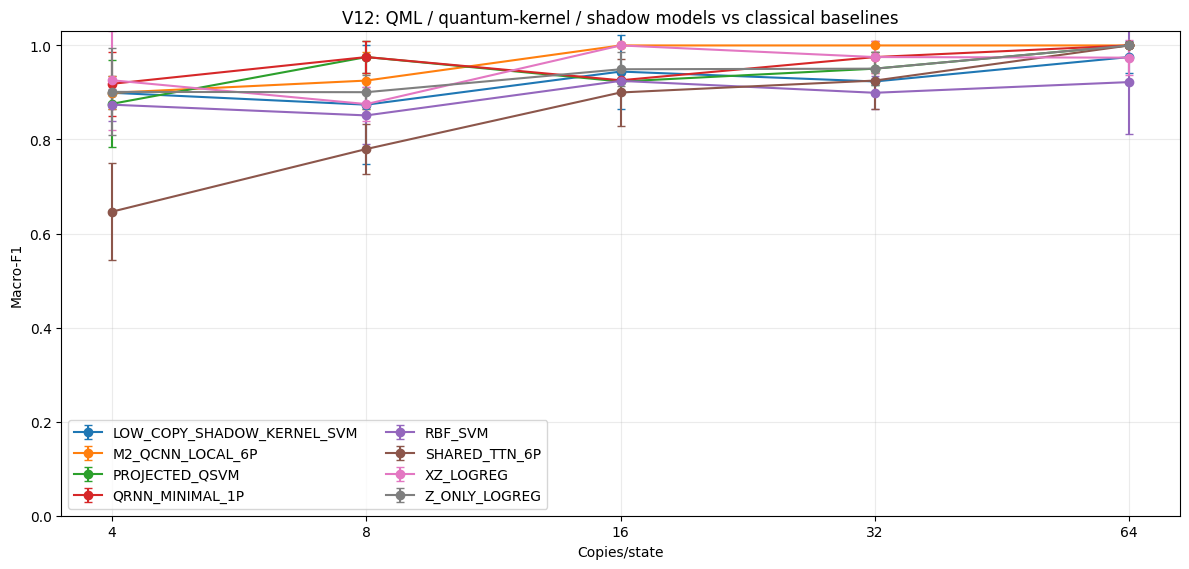

In [84]:
# ============================================================
# 35. Quantum/research models vs classical baselines
# ============================================================
comparison_df=pd.concat([final_df,baseline_df],ignore_index=True,sort=False)
fig,ax=plt.subplots(figsize=(12,5.8))
for model,g in comparison_df.groupby("model"):
    g=g.sort_values("budget"); ax.errorbar(g["budget"],g["macro_f1_mean"],yerr=g["macro_f1_std"],marker="o",capsize=3,label=model)
ax.set_xscale("log",base=2); ax.set_xticks(BUDGETS,[str(x) for x in BUDGETS]); ax.set_ylim(0,1.03)
ax.set_xlabel("Copies/state"); ax.set_ylabel("Macro-F1"); ax.set_title("V12: QML / quantum-kernel / shadow models vs classical baselines")
ax.grid(alpha=.25); ax.legend(ncol=2); plt.tight_layout(); plt.savefig(RESULTS_DIR/"all_models_vs_classical.png",dpi=190); plt.show()


In [85]:
# ============================================================
# 36. Resource accounting
# ============================================================
def direct_resource_estimate(model,N):
    N=int(N)
    if model=="M2_QCNN_LOCAL_6P":
        return {"one_qubit_gates_per_copy":3*N,"two_qubit_gates_per_copy":N,"depth_scaling":"O(1) ideal brickwork","params":6}
    if model=="QRNN_MINIMAL_1P":
        return {"one_qubit_gates_per_copy":N-1,"two_qubit_gates_per_copy":2*(N-1),"depth_scaling":"O(N)","params":1}
    if model=="SHARED_TTN_6P":
        return {"one_qubit_gates_per_copy":4*(N-1),"two_qubit_gates_per_copy":3*(N-1),"depth_scaling":"O(log N) tree levels","params":6}
    if model=="SHARED_MERA_8P":
        return {"one_qubit_gates_per_copy":6*(N-1),"two_qubit_gates_per_copy":5*(N-1),"depth_scaling":"O(log N) multiscale","params":8}
    raise ValueError(model)

resource_rows=[]
for model in ACTIVE_DIRECT_MODELS:
    for N in [4,8,16,32,64]: resource_rows.append({"model":model,"N":N,**direct_resource_estimate(model,N),"unknown_state_measurement_bases":"direct learned circuit"})
for model,bases in [("PROJECTED_QSVM","X/Z"),("LOW_COPY_SHADOW_KERNEL_SVM","X/Y/Z")]:
    for N in [4,8,16,32,64]:
        resource_rows.append({"model":model,"N":N,"one_qubit_gates_per_copy":N if bases!="Z" else 0,"two_qubit_gates_per_copy":0,"depth_scaling":"O(1) local basis rotations","params":0,"unknown_state_measurement_bases":bases})
resource_df=pd.DataFrame(resource_rows); display(resource_df); resource_df.to_csv(RESULTS_DIR/"resource_accounting.csv",index=False)


,model,N,one_qubit_gates_per_copy,two_qubit_gates_per_copy,depth_scaling,params,unknown_state_measurement_bases
0,M2_QCNN_LOCAL_6P,4,12,4,O(1) ideal brickwork,6,direct learned circuit
1,M2_QCNN_LOCAL_6P,8,24,8,O(1) ideal brickwork,6,direct learned circuit
2,M2_QCNN_LOCAL_6P,16,48,16,O(1) ideal brickwork,6,direct learned circuit
3,M2_QCNN_LOCAL_6P,32,96,32,O(1) ideal brickwork,6,direct learned circuit
4,M2_QCNN_LOCAL_6P,64,192,64,O(1) ideal brickwork,6,direct learned circuit
5,QRNN_MINIMAL_1P,4,3,6,O(N),1,direct learned circuit
6,QRNN_MINIMAL_1P,8,7,14,O(N),1,direct learned circuit
7,QRNN_MINIMAL_1P,16,15,30,O(N),1,direct learned circuit
8,QRNN_MINIMAL_1P,32,31,62,O(N),1,direct learned circuit
9,QRNN_MINIMAL_1P,64,63,126,O(N),1,direct learned circuit


In [86]:
# ============================================================
# 37. Optional matched readout-bitflip stress
# This is a cross-family measurement/readout stress, NOT organizer depolarizing noise.
# ============================================================
NOISE_ROWS=[]
if RUN_READOUT_NOISE_STRESS:
    noise_seeds=REPORT_SEEDS[:5] if len(REPORT_SEEDS)>5 else REPORT_SEEDS
    for model in PRIMARY_MODELS:
        for p in READOUT_NOISE_LEVELS:
            for b in SCORED_BUDGETS:
                ev=evaluate_model_public(model,VAL_IDX,b,noise_seeds,readout_p=p)
                NOISE_ROWS.append({"model":model,"readout_p":p,"budget":b,"macro_f1_mean":ev["mean"],"macro_f1_std":ev["std"]})
    noise_df=pd.DataFrame(NOISE_ROWS); display(noise_df); noise_df.to_csv(RESULTS_DIR/"matched_readout_noise_stress.csv",index=False)
else:
    noise_df=pd.DataFrame(); print("Readout-noise stress skipped.")


Readout-noise stress skipped.


# 38. Optional external development evidence

If legitimate non-hidden development files are attached, V12 evaluates them with the **already frozen** model-family hyperparameters:

- `xxz_near_critical_dev.npz`
- `generic_ood_dev.npz` or `fermi_hubbard_ood_dev.npz`
- `xxz_size_transfer_dev.npz` / `xxz_cross_size_dev.npz`

External qspin augmentation is **disabled by default**. It must not silently enter the training set without an explicit organizer ruling.


In [87]:
# ============================================================
# 38A. External dataset loader + arbitrary-N measurement simulators
# ============================================================
def load_external_npz(path):
    d=np.load(path,allow_pickle=True); raw=d["states"]
    if np.asarray(raw).dtype==object:
        states=[np.asarray(x,np.complex128).reshape(-1) for x in raw]
    else:
        mat=to_complex_matrix(raw); states=[mat[i] for i in range(len(mat))]
    states=[s/np.linalg.norm(s) for s in states]
    return {"states":states,"labels":np.asarray(d["labels"]).astype(str) if "labels" in d.files else None,"deltas":np.asarray(d["deltas"],float) if "deltas" in d.files else None,"ids":np.asarray(d["ids"]).astype(str) if "ids" in d.files else np.asarray([f"ext_{i}" for i in range(len(states))]),"num_qubits":np.asarray([int(round(np.log2(len(s)))) for s in states],int)}

_EXTERNAL_DIRECT_QNODES={}; _EXTERNAL_MEAS_QNODES={}
def external_direct_probs(state,arch,params,parity):
    n=int(round(np.log2(len(state)))); key=(n,arch,int(parity))
    if key not in _EXTERNAL_DIRECT_QNODES:
        dev=qml.device("default.qubit",wires=n,shots=None); builder=DIRECT_ARCHITECTURES[arch]["builder"]
        @qml.qnode(dev)
        def circ(s,p):
            qml.StatePrep(s,wires=range(n),normalize=True); builder(p,parity=int(parity))(range(n)); return qml.probs(wires=range(n))
        _EXTERNAL_DIRECT_QNODES[key]=circ
    p=np.asarray(_EXTERNAL_DIRECT_QNODES[key](state,params),float); p=np.maximum(p,0); p/=p.sum(); return p

def external_measure_probs(state,basis):
    n=int(round(np.log2(len(state)))); key=(n,basis)
    if key not in _EXTERNAL_MEAS_QNODES:
        dev=qml.device("default.qubit",wires=n,shots=None)
        @qml.qnode(dev)
        def circ(s):
            qml.StatePrep(s,wires=range(n),normalize=True)
            if basis=="X":
                for w in range(n): qml.Hadamard(wires=w)
            elif basis=="Y":
                for w in range(n): qml.adjoint(qml.S)(wires=w); qml.Hadamard(wires=w)
            return qml.probs(wires=range(n))
        _EXTERNAL_MEAS_QNODES[key]=circ
    p=np.asarray(_EXTERNAL_MEAS_QNODES[key](state),float); p=np.maximum(p,0); p/=p.sum(); return p

def simulate_external_direct(state,model,budget,seed):
    n=int(round(np.log2(len(state)))); params=FROZEN_MODELS[model]["params"]; shots=[]
    for shot_id in range(int(budget)):
        parity=shot_id%2; p=external_direct_probs(state,model,params,parity); out=sample_index_from_uniform(p,deterministic_uniform(seed,shot_id)); shots.append((parity,index_to_bits(out,n)))
    return aggregate_direct_episode(shots)

def simulate_external_neutral(state,budget,seed):
    n=int(round(np.log2(len(state)))); zr=[]; xr=[]; zc=int(budget)//2
    for shot_id in range(int(budget)):
        basis="Z" if shot_id<zc else "X"; p=external_measure_probs(state,basis); out=sample_index_from_uniform(p,deterministic_uniform(seed,shot_id)); f=axis_bit_feature(index_to_bits(out,n)); (zr if basis=="Z" else xr).append(f)
    return np.concatenate([np.mean(zr,axis=0) if zr else np.zeros(3),np.mean(xr,axis=0) if xr else np.zeros(3)])

def simulate_external_shadow(state,budget,seed):
    n=int(round(np.log2(len(state)))); rows={"X":[],"Y":[],"Z":[]}
    for shot_id in range(int(budget)):
        basis=shadow_basis_schedule(seed,shot_id); p=external_measure_probs(state,basis); out=sample_index_from_uniform(p,deterministic_uniform(seed+7919,shot_id)); rows[basis].append(axis_bit_feature(index_to_bits(out,n)))
    return np.concatenate([np.mean(rows[b],axis=0) if rows[b] else np.zeros(3) for b in ["X","Y","Z"]])


In [88]:
# ============================================================
# 39. One-class compatibility gates in each model's own measured feature space
# ============================================================
def fit_mahalanobis_gate(X,quantile=0.995):
    X=np.asarray(X,float); mu=X.mean(axis=0); cov=np.cov(X.T)+1e-3*np.eye(X.shape[1]); inv=np.linalg.pinv(cov); d=X-mu; d2=np.einsum("ni,ij,nj->n",d,inv,d)
    return {"mu":mu,"inv":inv,"threshold":float(np.quantile(d2,quantile))}

def gate_distance(X,gate):
    X=np.atleast_2d(np.asarray(X,float)); d=X-gate["mu"]; return np.einsum("ni,ij,nj->n",d,gate["inv"],d)

ONECLASS_GATES={}
for model in PRIMARY_MODELS:
    ONECLASS_GATES[model]={}
    for b in BUDGETS:
        if model in DIRECT_ARCHITECTURES:
            X,_=build_direct_episodes(FIT_IDX,model,FROZEN_MODELS[model]["params"],b,8,730000+b)
        elif model=="PROJECTED_QSVM":
            X,_=build_neutral_episodes(FIT_IDX,b,8,740000+b)
        else:
            X,_=build_shadow_episodes(FIT_IDX,b,8,750000+b)
        ONECLASS_GATES[model][b]=fit_mahalanobis_gate(X,0.995)
print("One-class compatibility gates: READY")


One-class compatibility gates: READY


In [89]:
# ============================================================
# 39B. Safe OOD-threshold calibration using KNOWN near-critical XXZ only
# Never calibrate on OOD/impostor labels.
# ============================================================
NEAR_CRITICAL_GATE_CALIBRATED = False
GATE_CALIBRATION_ROWS = []
if NEAR_CRITICAL_DEV is not None:
    _near = load_external_npz(NEAR_CRITICAL_DEV)
    if _near["labels"] is not None:
        for model in PRIMARY_MODELS:
            for b in SCORED_BUDGETS:
                feats=[]
                for i,state in enumerate(_near["states"]):
                    for seed in REPORT_SEEDS:
                        s=int(seed+880000+100000*i+17*b)
                        if model in DIRECT_ARCHITECTURES:
                            feat=simulate_external_direct(state,model,b,s)
                        elif model=="PROJECTED_QSVM":
                            feat=simulate_external_neutral(state,b,s)
                        else:
                            feat=simulate_external_shadow(state,b,s)
                        feats.append(feat)
                g=ONECLASS_GATES[model][b]
                raw=float(g["threshold"])
                protection=float(np.quantile(gate_distance(feats,g),0.995))
                g["raw_threshold"]=raw
                g["threshold"]=max(raw,protection)
                GATE_CALIBRATION_ROWS.append({"model":model,"budget":b,"raw_threshold":raw,"near_critical_protection_threshold":protection,"final_threshold":float(g["threshold"])})
        NEAR_CRITICAL_GATE_CALIBRATED=True
        gate_calibration_df=pd.DataFrame(GATE_CALIBRATION_ROWS)
        gate_calibration_df.to_csv(RESULTS_DIR/"near_critical_gate_calibration.csv",index=False)
        display(gate_calibration_df)
else:
    print("Near-critical gate calibration unavailable; raw train-domain gate retained.")


Near-critical gate calibration unavailable; raw train-domain gate retained.


In [90]:
# ============================================================
# 40. External prediction with frozen phase model + one-class gate
# ============================================================
def predict_external_known(model,state,budget,seed):
    if model in DIRECT_ARCHITECTURES:
        feat=simulate_external_direct(state,model,budget,seed); pred=str(FROZEN_MODELS[model]["heads"][budget].predict([feat])[0])
    elif model=="PROJECTED_QSVM":
        feat=simulate_external_neutral(state,budget,seed); pred=str(predict_projected_qsvm(FROZEN_MODELS[model]["budget_models"][budget],[feat])[0])
    elif model=="LOW_COPY_SHADOW_KERNEL_SVM":
        feat=simulate_external_shadow(state,budget,seed); pred=str(predict_shadow_svm(FROZEN_MODELS[model]["budget_models"][budget],[feat])[0])
    else:
        raise ValueError(model)
    rejected=bool(gate_distance([feat],ONECLASS_GATES[model][budget])[0]>ONECLASS_GATES[model][budget]["threshold"])
    return ("UNKNOWN" if rejected else pred),rejected


In [91]:
# ============================================================
# 41. Optional near-critical / OOD / size-transfer evidence
# ============================================================
EVIDENCE_STATUS={"near_critical":"UNVERIFIED","ood":"UNVERIFIED","size_transfer":"UNVERIFIED"}
EVIDENCE_TABLES={}

if NEAR_CRITICAL_DEV is not None:
    d=load_external_npz(NEAR_CRITICAL_DEV)
    if d["labels"] is not None:
        rows=[]
        for model in PRIMARY_MODELS:
            for b in SCORED_BUDGETS:
                yt=[]; yp=[]; rejects=[]
                for i,state in enumerate(d["states"]):
                    for seed in REPORT_SEEDS:
                        pred,rej=predict_external_known(model,state,b,int(seed+100000*i+17*b)); yt.append(str(d["labels"][i])); yp.append(pred); rejects.append(rej)
                rows.append({"model":model,"budget":b,"macro_f1":float(f1_score(yt,yp,labels=LABEL_ORDER,average="macro",zero_division=0)),"false_unknown_rate":float(np.mean(rejects))})
        near_df=pd.DataFrame(rows); EVIDENCE_TABLES["near_critical"]=near_df; EVIDENCE_STATUS["near_critical"]="MEASURED"; near_df.to_csv(RESULTS_DIR/"near_critical.csv",index=False); display(near_df)
else:
    print("Near-critical: UNVERIFIED")

if OOD_DEV is not None:
    d=load_external_npz(OOD_DEV); rows=[]
    for model in PRIMARY_MODELS:
        for b in SCORED_BUDGETS:
            ybin=[]; pbin=[]
            for idx in VAL_IDX:
                for seed in REPORT_SEEDS:
                    feat=model_feature(model,int(idx),b,int(seed+100000*idx+17*b)); rej=gate_distance([feat],ONECLASS_GATES[model][b])[0]>ONECLASS_GATES[model][b]["threshold"]; ybin.append(0); pbin.append(int(rej))
            for i,state in enumerate(d["states"]):
                for seed in REPORT_SEEDS:
                    _,rej=predict_external_known(model,state,b,int(seed+500000+100000*i+17*b)); ybin.append(1); pbin.append(int(rej))
            rows.append({"model":model,"budget":b,"ood_precision":float(precision_score(ybin,pbin,zero_division=0)),"ood_recall":float(recall_score(ybin,pbin,zero_division=0)),"ood_f1":float(f1_score(ybin,pbin,zero_division=0))})
    ood_df=pd.DataFrame(rows); EVIDENCE_TABLES["ood"]=ood_df; EVIDENCE_STATUS["ood"]="MEASURED"; ood_df.to_csv(RESULTS_DIR/"ood.csv",index=False); display(ood_df)
else:
    print("OOD: UNVERIFIED")

size_sources = ([SIZE_TRANSFER_DEV] if SIZE_TRANSFER_DEV is not None else []) + list(SIZE_TRANSFER_PARTS)
if size_sources:
    rows=[]
    for source_id,source in enumerate(size_sources):
        d=load_external_npz(source)
        if d["labels"] is None:
            continue
        for model in PRIMARY_MODELS:
            for N in sorted(set(d["num_qubits"].tolist())):
                sel=np.where(d["num_qubits"]==N)[0]
                for b in SCORED_BUDGETS:
                    ss=[]
                    for seed in REPORT_SEEDS:
                        yt=[]; yp=[]
                        for i in sel:
                            pred,_=predict_external_known(model,d["states"][i],b,int(seed+100000*i+17*b)); yt.append(str(d["labels"][i])); yp.append(pred)
                        ss.append(f1_score(yt,yp,labels=LABEL_ORDER,average="macro",zero_division=0))
                    rows.append({"source":str(source),"model":model,"N":int(N),"budget":b,"macro_f1_mean":float(np.mean(ss)),"macro_f1_std":float(np.std(ss))})
    if rows:
        size_df=pd.DataFrame(rows); EVIDENCE_TABLES["size_transfer"]=size_df; EVIDENCE_STATUS["size_transfer"]="MEASURED"; size_df.to_csv(RESULTS_DIR/"size_transfer.csv",index=False); display(size_df)
    else:
        print("Size transfer files found but no labeled states were available.")
else:
    print("Size transfer: UNVERIFIED")

print("Evidence status:",EVIDENCE_STATUS)


Near-critical: UNVERIFIED
OOD: UNVERIFIED
Size transfer: UNVERIFIED
Evidence status: {'near_critical': 'UNVERIFIED', 'ood': 'UNVERIFIED', 'size_transfer': 'UNVERIFIED'}


In [92]:
# ============================================================
# 42. External-qspin augmentation ruling firewall
# ============================================================
QSPIN_AUGMENTATION_STATUS = "DISABLED_BY_DEFAULT"
if ALLOW_EXTERNAL_QSPIN_AUGMENTATION:
    QSPIN_AUGMENTATION_STATUS = "EXPLICITLY_ALLOWED_BY_USER_ENV_BUT_NOT_USED_AUTOMATICALLY"
    print("External qspin augmentation was explicitly enabled, but V12 still does NOT silently add external states.")
    print("Attach/version a ruled-in augmentation dataset and add it through an explicit provenance-locked cell before rerunning selection.")
else:
    print("External qspin augmentation excluded from all V12 primary results.")


External qspin augmentation excluded from all V12 primary results.


In [93]:
# ============================================================
# 43. Deployment eligibility / claim discipline
# ============================================================
eligibility=[]
for model in PRIMARY_MODELS:
    if model in DIRECT_ARCHITECTURES:
        eligibility.append({"model":model,"direct_ops_on_unknown_state":True,"auxiliary_quantum_runtime_required":False,"primary_submission_eligible_in_principle":True,"note":"Still requires final organizer evaluator audit and evidence gates."})
    elif model=="PROJECTED_QSVM":
        eligibility.append({"model":model,"direct_ops_on_unknown_state":False,"auxiliary_quantum_runtime_required":True,"primary_submission_eligible_in_principle":False,"note":"Research comparator until auxiliary projected-kernel runtime is explicitly permitted."})
    else:
        eligibility.append({"model":model,"direct_ops_on_unknown_state":False,"auxiliary_quantum_runtime_required":False,"primary_submission_eligible_in_principle":False,"note":"Fixed shadow-style measurement/kernel comparator; not the primary trainable-circuit submission."})
DEPLOYMENT_ELIGIBILITY=pd.DataFrame(eligibility); display(DEPLOYMENT_ELIGIBILITY); DEPLOYMENT_ELIGIBILITY.to_csv(RESULTS_DIR/"deployment_eligibility.csv",index=False)


,model,direct_ops_on_unknown_state,auxiliary_quantum_runtime_required,primary_submission_eligible_in_principle,note
0,M2_QCNN_LOCAL_6P,True,False,True,Still requires final organizer evaluator audit...
1,QRNN_MINIMAL_1P,True,False,True,Still requires final organizer evaluator audit...
2,SHARED_TTN_6P,True,False,True,Still requires final organizer evaluator audit...
3,PROJECTED_QSVM,False,True,False,Research comparator until auxiliary projected-...
4,LOW_COPY_SHADOW_KERNEL_SVM,False,False,False,Fixed shadow-style measurement/kernel comparat...


In [94]:
# ============================================================
# 44. Final promotion / evidence matrix
# ============================================================
promotion=[]
def add_gate(gate,status,value=None,note=None): promotion.append({"gate":gate,"status":status,"value":value,"note":note})

add_gate("Dataset integrity", "PASS")
add_gate("Physical-diversity / fidelity geometry audited", "PASS", value=fidelity_gram_erank)
add_gate("Primary nested state-level selection", "PASS")
add_gate("Boundary-proxy stress split", "PASS" if len(stress_df) else "UNVERIFIED")
add_gate("Fidelity-gap stress split", "PASS" if len(stress_df) else "UNVERIFIED")
add_gate("Copy budgets 4/8/16/32/64 reported", "PASS" if set(BUDGETS).issubset(set(final_df["budget"])) else "FAIL")
add_gate("Direct trainable parameter count independent of N", "PASS")

# Hierarchical significance for best direct model vs direct runner-up.
DIRECT_RUNNER_UP=str(DIRECT_RANKING.iloc[1]["model"]) if len(DIRECT_RANKING)>1 else None
if DIRECT_RUNNER_UP:
    sig=hierarchical_bootstrap_margin(DIRECT_PUBLIC_WINNER,DIRECT_RUNNER_UP,n_boot=BOOTSTRAP_REPS,seed=9090)
    sig_status="PASS" if sig["ci_low"]>0 else "FAIL"
    add_gate("Best direct model vs direct runner-up hierarchical separation",sig_status,value=sig["mean_margin"],note=f"95% CI [{sig['ci_low']:.4f}, {sig['ci_high']:.4f}]")
else:
    add_gate("Best direct model vs direct runner-up hierarchical separation","UNVERIFIED")

add_gate("Projected-kernel concentration diagnostics", "PASS" if not kernel_diag_df["concentration_warning"].any() else "WARN")
add_gate("Unique-state learning curves", "PASS" if RUN_LEARNING_CURVES and len(learning_curve_df) else "UNVERIFIED")
add_gate("Matched readout-noise stress", "PASS" if RUN_READOUT_NOISE_STRESS and len(noise_df) else "UNVERIFIED", note="Not organizer depolarizing noise.")
if EVIDENCE_STATUS["near_critical"]=="MEASURED":
    r=EVIDENCE_TABLES["near_critical"]; r=r[r["model"]==DIRECT_PUBLIC_WINNER]
    near_f1=float(r["macro_f1"].mean()); near_fu=float(r["false_unknown_rate"].mean())
    near_pass=near_f1>=INTERNAL_GATES["min_near_critical_macro_f1"] and near_fu<=INTERNAL_GATES["max_near_critical_false_unknown_rate"]
    add_gate("Near-critical development evidence", "PASS" if near_pass else "FAIL", value=near_f1, note=f"mean false UNKNOWN={near_fu:.4f}")
else:
    add_gate("Near-critical development evidence", "UNVERIFIED")

if EVIDENCE_STATUS["ood"]=="MEASURED":
    r=EVIDENCE_TABLES["ood"]; r=r[r["model"]==DIRECT_PUBLIC_WINNER]
    op=float(r["ood_precision"].mean()); orc=float(r["ood_recall"].mean())
    ood_pass=op>=INTERNAL_GATES["min_ood_precision"] and orc>=INTERNAL_GATES["min_ood_recall"]
    add_gate("OOD/UNKNOWN development evidence", "PASS" if ood_pass else "FAIL", value=f"P={op:.4f}, R={orc:.4f}")
else:
    add_gate("OOD/UNKNOWN development evidence", "UNVERIFIED")

if EVIDENCE_STATUS["size_transfer"]=="MEASURED":
    r=EVIDENCE_TABLES["size_transfer"]; r=r[r["model"]==DIRECT_PUBLIC_WINNER]
    transfer=float(r["macro_f1_mean"].mean())
    add_gate("Empirical size-transfer evidence", "PASS" if transfer>=INTERNAL_GATES["min_size_transfer_macro_f1"] else "FAIL", value=transfer)
else:
    add_gate("Empirical size-transfer evidence", "UNVERIFIED")
add_gate("Organizer hidden leakage firewall", "PASS", value=False)
add_gate("External qspin augmentation excluded unless explicitly ruled in", "PASS", value=QSPIN_AUGMENTATION_STATUS)

promotion_df=pd.DataFrame(promotion); display(promotion_df); promotion_df.to_csv(RESULTS_DIR/"promotion_matrix.csv",index=False)

MANDATORY_FOR_NEW_PROMOTION=[
    "Dataset integrity","Physical-diversity / fidelity geometry audited","Primary nested state-level selection",
    "Boundary-proxy stress split","Fidelity-gap stress split","Copy budgets 4/8/16/32/64 reported",
    "Direct trainable parameter count independent of N","Best direct model vs direct runner-up hierarchical separation",
    "Near-critical development evidence","OOD/UNKNOWN development evidence","Empirical size-transfer evidence","Organizer hidden leakage firewall",
]
mandatory=promotion_df[promotion_df["gate"].isin(MANDATORY_FOR_NEW_PROMOTION)]
ALL_PROMOTION_GATES_PASS=bool(len(mandatory)==len(MANDATORY_FOR_NEW_PROMOTION) and (mandatory["status"]=="PASS").all())
DEPLOYMENT_DECISION=DIRECT_PUBLIC_WINNER if ALL_PROMOTION_GATES_PASS else "KEEP_VALIDATED_INCUMBENT"
print("DIRECT PUBLIC WINNER:",DIRECT_PUBLIC_WINNER)
print("DEPLOYMENT DECISION:",DEPLOYMENT_DECISION)


,gate,status,value,note
0,Dataset integrity,PASS,None,None
1,Physical-diversity / fidelity geometry audited,PASS,3.156603,None
2,Primary nested state-level selection,PASS,None,None
3,Boundary-proxy stress split,PASS,None,None
4,Fidelity-gap stress split,PASS,None,None
5,Copy budgets 4/8/16/32/64 reported,PASS,None,None
6,Direct trainable parameter count independent of N,PASS,None,None
7,Best direct model vs direct runner-up hierarch...,FAIL,0.007172,"95% CI [-0.0581, 0.0683]"
8,Projected-kernel concentration diagnostics,PASS,None,None
9,Unique-state learning curves,UNVERIFIED,None,None


DIRECT PUBLIC WINNER: QRNN_MINIMAL_1P
DEPLOYMENT DECISION: KEEP_VALIDATED_INCUMBENT


# 45. Competition submission export

The export cell packages **only a direct-state model**. If all V12 promotion gates pass, it exports the promoted direct winner. Otherwise it still allows an experimental candidate package for organizer testing, but labels it explicitly as **not promoted**. Kernel/shadow research models are never silently exported as the primary submission.


In [95]:
# ============================================================
# 45A. Serialize direct winner + heads + one-class gates
# ============================================================
def serialize_linear_pipeline(pipe):
    scaler=pipe.named_steps["standardscaler"]; lr=pipe.named_steps["logisticregression"]
    return {"classes":lr.classes_.astype(str).tolist(),"scaler_mean":np.asarray(scaler.mean_,float).tolist(),"scaler_scale":np.asarray(scaler.scale_,float).tolist(),"coef":np.asarray(lr.coef_,float).tolist(),"intercept":np.asarray(lr.intercept_,float).tolist()}

def serialize_gate(g):
    return {"mu":np.asarray(g["mu"],float).tolist(),"inv":np.asarray(g["inv"],float).tolist(),"threshold":float(g["threshold"])}

EXPORT_ARCH=DIRECT_PUBLIC_WINNER if DEPLOYMENT_DECISION=="KEEP_VALIDATED_INCUMBENT" else DEPLOYMENT_DECISION
EXPORT_STATUS="PROMOTED_V12_DIRECT_MODEL" if ALL_PROMOTION_GATES_PASS else "EXPERIMENTAL_DIRECT_PUBLIC_WINNER_NOT_PROMOTED"
EXPORT_BUILD=ARTIFACTS_DIR/"submission_build"; EXPORT_BUILD.mkdir(parents=True,exist_ok=True)

cfg={"version":"AQH_V12_DIRECT_EXPORT","architecture":EXPORT_ARCH,"status":EXPORT_STATUS,"params":np.asarray(FROZEN_MODELS[EXPORT_ARCH]["params"],float).tolist(),"parameter_count":int(DIRECT_ARCHITECTURES[EXPORT_ARCH]["n_params"]),"parameter_count_depends_on_N":False,"allowed_budgets":BUDGETS,"budgets":{}}
for b in BUDGETS:
    cfg["budgets"][str(b)]={"phase_head":serialize_linear_pipeline(FROZEN_MODELS[EXPORT_ARCH]["heads"][b]),"oneclass":serialize_gate(ONECLASS_GATES[EXPORT_ARCH][b])}
(EXPORT_BUILD/"model_config.json").write_text(json.dumps(cfg,indent=2),encoding="utf-8")
print("Export architecture:",EXPORT_ARCH)
print("Export status:",EXPORT_STATUS)


Export architecture: QRNN_MINIMAL_1P
Export status: EXPERIMENTAL_DIRECT_PUBLIC_WINNER_NOT_PROMOTED


In [96]:
# ============================================================
# 45B. Generate universal direct-state submission.py
# ============================================================
SUBMISSION_SOURCE = r'''from pathlib import Path
import json, numpy as np
import pennylane as qml
HERE=Path(__file__).resolve().parent
MODEL=json.loads((HERE/'model_config.json').read_text(encoding='utf-8'))
ARCH=MODEL['architecture']; PARAMS=np.asarray(MODEL['params'],float); BUDGETS=[4,8,16,32,64]

def pair_starts(n,parity):
    s=list(range(int(parity),int(n)-1,2))
    if int(n)%2==0 and int(parity)==1: s.append(int(n)-1)
    return s

def m2_ops(parity):
    p=PARAMS
    def ops(wires):
        n=len(wires)
        for a in pair_starts(n,parity):
            b=(a+1)%n; qml.RY(float(p[0]),wires=a); qml.RY(float(p[1]),wires=b); qml.CNOT(wires=[a,b]); qml.RZ(float(p[2]),wires=b)
        for a in pair_starts(n,1-int(parity)):
            b=(a+1)%n; qml.RY(float(p[3]),wires=a); qml.CNOT(wires=[b,a]); qml.RX(float(p[4]),wires=b); qml.RZ(float(p[5]),wires=a)
    return ops

def qrnn_ops(parity):
    theta=float(PARAMS[0])
    def cell(a,b): qml.RY(theta,wires=a); qml.CNOT(wires=[a,b]); qml.CNOT(wires=[b,a])
    def ops(wires):
        n=len(wires)
        if int(parity)==0:
            for a in range(n-1): cell(a,a+1)
        else:
            for a in range(n-1,0,-1): cell(a,a-1)
    return ops

def ttn_block(a,b,p):
    qml.RY(float(p[0]),wires=a); qml.RY(float(p[1]),wires=b); qml.IsingXX(float(p[2]),wires=[a,b]); qml.IsingZZ(float(p[3]),wires=[a,b]); qml.CNOT(wires=[a,b]); qml.RY(float(p[4]),wires=b); qml.RZ(float(p[5]),wires=b)

def ttn_ops(parity):
    p=PARAMS
    def ops(wires):
        active=list(wires)
        if int(parity)==1: active=active[1:]+active[:1]
        while len(active)>1:
            nxt=[]; i=0
            while i+1<len(active):
                a,b=active[i],active[i+1]; ttn_block(a,b,p); nxt.append(b); i+=2
            if i<len(active): nxt.append(active[i])
            active=nxt
    return ops

def mera_dis(a,b,p): qml.IsingXX(float(p[0]),wires=[a,b]); qml.IsingYY(float(p[1]),wires=[a,b]); qml.RZ(float(p[2]),wires=a); qml.RZ(float(p[3]),wires=b)
def mera_pool(a,b,p): qml.CNOT(wires=[a,b]); qml.RY(float(p[4]),wires=b); qml.IsingZZ(float(p[5]),wires=[a,b]); qml.RX(float(p[6]),wires=a); qml.RZ(float(p[7]),wires=b)
def mera_ops(parity):
    p=PARAMS
    def ops(wires):
        active=list(wires)
        if int(parity)==1: active=active[1:]+active[:1]
        while len(active)>1:
            for i in range(1,len(active)-1,2): mera_dis(active[i],active[i+1],p)
            nxt=[]; i=0
            while i+1<len(active):
                a,b=active[i],active[i+1]; mera_pool(a,b,p); nxt.append(b); i+=2
            if i<len(active): nxt.append(active[i])
            active=nxt
    return ops

def ops_builder(parity):
    if ARCH=='M2_QCNN_LOCAL_6P': return m2_ops(parity)
    if ARCH=='QRNN_MINIMAL_1P': return qrnn_ops(parity)
    if ARCH=='SHARED_TTN_6P': return ttn_ops(parity)
    if ARCH=='SHARED_MERA_8P': return mera_ops(parity)
    raise ValueError(ARCH)

def shot_feature(bits,parity):
    bits=np.asarray(bits,int).reshape(-1); n=len(bits); z=1.-2.*bits; c=[];t=[];pr=[]
    for a in pair_starts(n,parity):
        b=(a+1)%n; c.append(z[a]); t.append(z[b]); pr.append(z[a]*z[b])
    return np.asarray([np.mean(c) if c else 0.,np.mean(t) if t else 0.,np.mean(pr) if pr else 0.,np.mean(z),np.mean(((-1.)**np.arange(n))*z),np.mean(z*np.roll(z,-1))],float)

def aggregate(shots):
    d={0:[],1:[]}
    for p,b in shots: d[int(p)].append(shot_feature(b,int(p)))
    return np.concatenate([np.mean(d[p],axis=0) if d[p] else np.zeros(6) for p in [0,1]])

def linear_predict(x,cfg):
    mean=np.asarray(cfg['scaler_mean'],float); scale=np.asarray(cfg['scaler_scale'],float); scale=np.where(np.abs(scale)<1e-12,1.,scale); z=(np.asarray(x,float)-mean)/scale
    coef=np.asarray(cfg['coef'],float); inter=np.asarray(cfg['intercept'],float); classes=np.asarray(cfg['classes'],str); return str(classes[int(np.argmax(coef@z+inter))])

def compatible(x,cfg):
    d=np.asarray(x,float)-np.asarray(cfg['mu'],float); return bool(float(d@np.asarray(cfg['inv'],float)@d)<=float(cfg['threshold']))

def choose_budget(n):
    valid=[b for b in BUDGETS if b<=int(n)]; return max(valid) if valid else max(0,int(n))

def classify(oracle,state_ids):
    out={}
    for sid in state_ids:
        sid=str(sid); available=int(getattr(oracle,'copy_budget',64))
        if hasattr(oracle,'remaining'): available=min(available,int(oracle.remaining(sid)))
        target=choose_budget(available); shots=[]
        for shot_id in range(target):
            if hasattr(oracle,'remaining') and oracle.remaining(sid)<=0: break
            parity=shot_id%2
            try: bits=oracle.measure(sid,ops_fn=ops_builder(parity))
            except Exception as exc:
                if exc.__class__.__name__=='CopyBudgetExceeded': break
                raise
            shots.append((parity,np.asarray(bits,np.int8)))
        if not shots: out[sid]='UNKNOWN'; continue
        feat=aggregate(shots); b=choose_budget(len(shots)); trained=sorted(int(k) for k in MODEL['budgets']); use=b if str(b) in MODEL['budgets'] else min(trained,key=lambda x:abs(x-b)); cfg=MODEL['budgets'][str(use)]
        pred=linear_predict(feat,cfg['phase_head']); out[sid]=pred if compatible(feat,cfg['oneclass']) else 'UNKNOWN'
    return out
'''

submission_path=EXPORT_BUILD/"submission.py"; submission_path.write_text(SUBMISSION_SOURCE,encoding="utf-8")
py_compile.compile(str(submission_path),doraise=True)
print("submission.py compile: PASS")


submission.py compile: PASS


In [97]:
# ============================================================
# 45C. Build submission ZIP + research evidence ZIP
# ============================================================
submission_zip=ROOT/"AQH_Track2_V12_Direct_Candidate_Submission.zip"
if submission_zip.exists(): submission_zip.unlink()
with zipfile.ZipFile(submission_zip,"w",compression=zipfile.ZIP_DEFLATED) as zf:
    zf.write(EXPORT_BUILD/"submission.py",arcname="submission.py")
    zf.write(EXPORT_BUILD/"model_config.json",arcname="model_config.json")

manifest={
    "version":"AQH_TRACK2_FINAL_V12_PHYSICS_FIRST",
    "run_mode":RUN_MODE,
    "public_research_winner":PUBLIC_RESEARCH_WINNER,
    "public_direct_winner":DIRECT_PUBLIC_WINNER,
    "deployment_decision":DEPLOYMENT_DECISION,
    "submission_export_architecture":EXPORT_ARCH,
    "submission_export_status":EXPORT_STATUS,
    "models":PRIMARY_MODELS,
    "budgets":BUDGETS,
    "report_seeds":REPORT_SEEDS,
    "hidden_used_for_selection":False,
    "dataset_geometry":{"state_gram_effective_rank":state_gram_erank,"fidelity_gram_effective_rank":fidelity_gram_erank,"public_near_critical_available":PUBLIC_NEAR_CRITICAL_AVAILABLE},
    "splits":{"fit":FIT_IDX.tolist(),"val":VAL_IDX.tolist(),"search_train":SEARCH_TRAIN_IDX.tolist(),"search_tune":SEARCH_TUNE_IDX.tolist(),"boundary_val":BOUNDARY_VAL_IDX.tolist(),"fidelity_gap_val":FIDGAP_VAL_IDX.tolist()},
    "direct_best_params":{k:np.asarray(v["params"],float).tolist() for k,v in DIRECT_BEST.items()},
    "projected_kernel_cfg":PROJECTED_BEST_CFG,
    "shadow_kernel_cfg":SHADOW_BEST_CFG,
    "evidence_status":EVIDENCE_STATUS,
    "qspin_augmentation_status":QSPIN_AUGMENTATION_STATUS,
}
manifest_path=ARTIFACTS_DIR/"V12_METHODS_MANIFEST.json"; manifest_path.write_text(json.dumps(manifest,indent=2),encoding="utf-8")

research_zip=ROOT/"AQH_Track2_V12_RESEARCH_EVIDENCE.zip"
if research_zip.exists(): research_zip.unlink()
with zipfile.ZipFile(research_zip,"w",compression=zipfile.ZIP_DEFLATED) as zf:
    zf.write(manifest_path,arcname=manifest_path.name)
    for p in sorted(RESULTS_DIR.rglob("*")):
        if p.is_file(): zf.write(p,arcname=str(Path("results")/p.name))

print("Submission ZIP:",submission_zip)
print("Research evidence ZIP:",research_zip)
print("IMPORTANT: if deployment_decision=KEEP_VALIDATED_INCUMBENT, the direct candidate ZIP is experimental only.")


Submission ZIP: /kaggle/working/AQH_Track2_V12_Direct_Candidate_Submission.zip
Research evidence ZIP: /kaggle/working/AQH_Track2_V12_RESEARCH_EVIDENCE.zip
IMPORTANT: if deployment_decision=KEEP_VALIDATED_INCUMBENT, the direct candidate ZIP is experimental only.


In [98]:
# ============================================================
# 46. FINAL V12 DASHBOARD
# ============================================================
print("="*118)
print("AQH 2026 TRACK 2 — FINAL V12 PHYSICS-FIRST / FEW-DATA DASHBOARD")
print("="*118)
print("\n[1] DATASET GEOMETRY")
print("Rows:",len(meta),"N:",N_PUBLIC,"Fidelity effective rank:",round(fidelity_gram_erank,5),"State-Gram effective rank:",round(state_gram_erank,5))
display(geometry_df)
print("\n[2] PRIMARY RESEARCH RANKING")
display(ranking_df)
print("\n[3] PRIMARY COPY-EFFICIENCY")
display(final_df)
print("\n[4] HIERARCHICAL STATE+SEED BOOTSTRAP")
display(bootstrap_df)
print("\n[5] STRESS SPLITS")
if len(stress_df): display(stress_df)
print("\n[6] PROJECTED KERNEL DIAGNOSTICS")
display(kernel_diag_df)
print("\n[7] CLASSICAL BASELINES")
display(baseline_df)
print("\n[8] RESOURCE ACCOUNTING")
display(resource_df)
print("\n[9] DEVELOPMENT EVIDENCE")
print(json.dumps(EVIDENCE_STATUS,indent=2))
print("\n[10] PROMOTION MATRIX")
display(promotion_df)
print("\n"+"="*118)
print("PUBLIC RESEARCH WINNER       :",PUBLIC_RESEARCH_WINNER)
print("BEST DIRECT-STATE CANDIDATE  :",DIRECT_PUBLIC_WINNER)
print("DEPLOYMENT DECISION          :",DEPLOYMENT_DECISION)
print("SUBMISSION EXPORT STATUS     :",EXPORT_STATUS)
print("HIDDEN USED FOR SELECTION    :",False)
print("EXTERNAL QSPIN IN PRIMARY RUN:",False)
print("="*118)
print("\nInterpretation: V12 prioritizes independent physical-state evidence over episode count. A new model is not promoted merely because it wins the smooth 48-state public interpolation problem.")


AQH 2026 TRACK 2 — FINAL V12 PHYSICS-FIRST / FEW-DATA DASHBOARD

[1] DATASET GEOMETRY
Rows: 48 N: 16 Fidelity effective rank: 3.1566 State-Gram effective rank: 2.70195


,label,n,pairwise_fidelity_mean,pairwise_fidelity_median,adjacent_delta_fidelity_mean,adjacent_delta_fidelity_min
0,FM,14,1.000000,1.000000,1.000000,1.000000
1,XY,20,0.901263,0.941240,0.998178,0.995644
2,NEEL,14,0.933113,0.961696,0.998005,0.997527



[2] PRIMARY RESEARCH RANKING


,model,weighted_low_copy_f1,mean_low_copy_std,stability_diagnostic,official_direct_runtime_candidate
0,QRNN_MINIMAL_1P,0.940228,0.034336,0.936794,True
1,M2_QCNN_LOCAL_6P,0.933592,0.032053,0.930387,True
2,PROJECTED_QSVM,0.922569,0.043096,0.918259,False
3,LOW_COPY_SHADOW_KERNEL_SVM,0.901754,0.080196,0.893734,False
4,SHARED_TTN_6P,0.756554,0.075280,0.749026,True



[3] PRIMARY COPY-EFFICIENCY


...


[8] RESOURCE ACCOUNTING


,model,N,one_qubit_gates_per_copy,two_qubit_gates_per_copy,depth_scaling,params,unknown_state_measurement_bases
0,M2_QCNN_LOCAL_6P,4,12,4,O(1) ideal brickwork,6,direct learned circuit
1,M2_QCNN_LOCAL_6P,8,24,8,O(1) ideal brickwork,6,direct learned circuit
2,M2_QCNN_LOCAL_6P,16,48,16,O(1) ideal brickwork,6,direct learned circuit
3,M2_QCNN_LOCAL_6P,32,96,32,O(1) ideal brickwork,6,direct learned circuit
4,M2_QCNN_LOCAL_6P,64,192,64,O(1) ideal brickwork,6,direct learned circuit
5,QRNN_MINIMAL_1P,4,3,6,O(N),1,direct learned circuit
6,QRNN_MINIMAL_1P,8,7,14,O(N),1,direct learned circuit
7,QRNN_MINIMAL_1P,16,15,30,O(N),1,direct learned circuit
8,QRNN_MINIMAL_1P,32,31,62,O(N),1,direct learned circuit
9,QRNN_MINIMAL_1P,64,63,126,O(N),1,direct learned circuit



[9] DEVELOPMENT EVIDENCE
{
  "near_critical": "UNVERIFIED",
  "ood": "UNVERIFIED",
  "size_transfer": "UNVERIFIED"
}

[10] PROMOTION MATRIX


,gate,status,value,note
0,Dataset integrity,PASS,None,None
1,Physical-diversity / fidelity geometry audited,PASS,3.156603,None
2,Primary nested state-level selection,PASS,None,None
3,Boundary-proxy stress split,PASS,None,None
4,Fidelity-gap stress split,PASS,None,None
5,Copy budgets 4/8/16/32/64 reported,PASS,None,None
6,Direct trainable parameter count independent of N,PASS,None,None
7,Best direct model vs direct runner-up hierarch...,FAIL,0.007172,"95% CI [-0.0581, 0.0683]"
8,Projected-kernel concentration diagnostics,PASS,None,None
9,Unique-state learning curves,UNVERIFIED,None,None



PUBLIC RESEARCH WINNER       : QRNN_MINIMAL_1P
BEST DIRECT-STATE CANDIDATE  : QRNN_MINIMAL_1P
DEPLOYMENT DECISION          : KEEP_VALIDATED_INCUMBENT
SUBMISSION EXPORT STATUS     : EXPERIMENTAL_DIRECT_PUBLIC_WINNER_NOT_PROMOTED
HIDDEN USED FOR SELECTION    : False
EXTERNAL QSPIN IN PRIMARY RUN: False

Interpretation: V12 prioritizes independent physical-state evidence over episode count. A new model is not promoted merely because it wins the smooth 48-state public interpolation problem.
